In [1]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from sklearn.decomposition import PCA
from itertools import combinations
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from dash import Dash, dcc, html, Input, Output, no_update
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from scipy.spatial.distance import pdist, squareform
from pathlib import Path
import prince
import dash
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import prince
from sklearn.model_selection import LeaveOneOut
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.linear_model import ElasticNet
from dash import dcc, html, Input, Output
from scipy.cluster.hierarchy import linkage, fcluster
from matplotlib.patches import Ellipse
from difflib import get_close_matches
from sklearn.impute import KNNImputer
import plotly.graph_objects as go
from dash import dcc, html, Input, Output
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.cross_decomposition import PLSRegression
from scipy.cluster.hierarchy import linkage, dendrogram
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN
import plotly.express as px
from sklearn.neighbors import NearestNeighbors



# Combining Sample and Control Files (qc, blank, env blank) for later removing contamination

In [2]:

# listing  the compounds samples data extracted by Nist library of unknown compound software
sample_files = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_9.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_14.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_21.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_28.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_44.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_53.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_55.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_83.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_92.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_6.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_10.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_38.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_42.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_48.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_56.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_76.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_79.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_86.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_5.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_16.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_39.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_50.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_60.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_68.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_81.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_87.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_66.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_4.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_8.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_37.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_43.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_51.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_57.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_61.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_18.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_75.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_94.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_1.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_35.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_30.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_71.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_73.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_88.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_93.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_12.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_36.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_15.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_25.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_40.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_41.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_45.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_59.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_74.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_77.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_49.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_2.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_24.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_31.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_32.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_34.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_90.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_58.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_64.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_70.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_78.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_22.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_26.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_47.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_52.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_65.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_67.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_54.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_80.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_82.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_85.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_3.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_13.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_17.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_20.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_23.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_27.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_29.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_62.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_72.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_11.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_19.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_33.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_46.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_63.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_69.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_84.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_89.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_91.csv",

]
#we want to remove the contamination and get the actual peaks for samples
qc_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\QC_*.csv")
env_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\env_*.csv")
blank_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\blank_*.csv")
all_files = (
    [(f,"sample") for f in sample_files] +
    [(f, "qc") for f in qc_files] +
    [(f, "env") for f in env_files] +
    [(f, "blank") for f in blank_files]
)
rows = []
for fp, ftype in all_files:
    df = pd.read_csv(fp)
    df["FileType"] = ftype
    df["FileName"] = fp.split("\\")[-1]
    rows.append(df)
compound_df = pd.concat(rows, ignore_index=True)
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv"

# Save to CSV to use it later
compound_df .to_csv(output_path, index=False)
print(f"compound dataset saved to: {output_path}")
compound_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\fatemehm\\OneDrive - Royal HZPC Group\\Desktop\\internship\\bio_rep1\\raw_data\\compounds\\day_1\\sample_7.csv'

# Filtering True Sample Compounds

In [ ]:
# removing the compounds of in blanks/QCs/env
exclude = compound_df.loc[
    compound_df['FileType'].isin(['blank', 'env', 'qc']),
    'Compound Name'
].unique()

# Keep only actual sample compounds, removing excluded ones
real = compound_df.loc[
    (compound_df['FileType'] == 'sample') &
    (~compound_df['Compound Name'].isin(exclude))
].copy()

# Print filtered data shape and show head
print("Filtered sample compounds:", real.shape)
real.head()

Filtered sample compounds: (2394, 7)


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Matching filtered sample dataset by compound dataset

In [ ]:

#  filtered data(prepared_data)
samples_filtered = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\save_results\samples_filtered.csv")

# Remove QC, ENV, BLANK 
samples_filtered = samples_filtered[
    ~samples_filtered['Filename'].str.contains("QC|ENV|BLANK", case=False, na=False)
].copy()

print(f"Samples kept after filtering: {samples_filtered['Filename'].nunique()} unique")


#  Build mapping dictionary
sample_mapping = {
    f"sample_{m.group(1)}.csv": col
    for col in samples_filtered['Filename'].unique()
    if (m := re.search(r"S96_(\d+)_B1_D\d+_T\d+", col))
}

#  add missing samples
sample_mapping['sample_46.csv'] = 'S96_46_B1_D10_T2'
sample_mapping['sample_47.csv'] = 'S96_47_B1_D8_T2'


#  closest RT matcher
def find_closest_peak(rt, peaks_rt, tol=0.3):
    diffs = np.abs(peaks_rt - rt)
    min_diff = diffs.min()
    if min_diff <= tol:
        return diffs.idxmin()
    else:
        return None


#  Load compounds & filter out 25
compound_df = compound_df[~compound_df['Component RT'].between(25.0, 25.7)]
print(f" Compounds kept after removing ~25 min RT: {compound_df.shape[0]}")


# Match compounds to samples
matches = []
unmatched = []

for i, row in compound_df.iterrows():
    file_name = row['FileName']  
    true_fname = sample_mapping.get(file_name)

    if true_fname is None:
        unmatched.append({**row, "Reason": "No mapping"})
        continue

    sample_data = samples_filtered[samples_filtered['Filename'] == true_fname]
    if sample_data.empty:
        unmatched.append({**row, "Reason": "No rows in samples_filtered"})
        continue

    compound_rt = row['Component RT']
    peak_idx = find_closest_peak(compound_rt, sample_data['tR_best'], tol=0.7)

    if peak_idx is None:
        unmatched.append({**row, "Reason": "No matching RT"})
        continue

    peak_row = sample_data.loc[peak_idx]

    matches.append({
        'Compound Name': row['Compound Name'],
        'FileName': file_name,
        'True_Filename': true_fname,
        'Variety': peak_row['Variety'],
        'Component RT': compound_rt,
        'Peak': peak_row['Peak'],
        'tR_best': peak_row['tR_best'],
        'm/z': peak_row['m/z'],
        'Intensity': peak_row['Intensity_corrected']
    })

compound_intensity_df = pd.DataFrame(matches)
unmatched_df = pd.DataFrame(unmatched)

print("Unique varieties:", compound_intensity_df['Variety'].nunique())

# Save results
compound_intensity_df.to_csv("compound_intensity_matched.csv", index=False)


Samples kept after filtering: 94 unique
 Compounds kept after removing ~25 min RT: 2386
Unique varieties: 94


# Checking the presence of known potato aroma compounds

In [ ]:
import pandas as pd
import numpy as np
from difflib import get_close_matches


potato_aromas = [
    "Hexanal", "Nonanal", "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "1-Octen-3-ol", "Benzaldehyde", "1-Phenylethanol", "Methional",
    "Dimethyl trisulfide", "Furfural", "2,3-Butanedione", "Ethyl butanoate",
    "2-Acetylpyrazine", "Dimethyl disulfide", "2-Propanone, 1-methoxy-",
    "3-Octanone", "Hexanol", "Butanal, 3-methyl-",
    "Heptanal", "Octanal", "Decanal",
    "2-Heptanone", "2-Nonanone", "3-Heptanone",
    "Ethyl hexanoate", "Methyl butanoate", "Ethyl 2-methylbutanoate",
    "2-Ethyl-3,5-dimethylpyrazine", "2-Isobutyl-3-methoxypyrazine",
    "1-Heptanol", "1-Nonanol",
    "Methanethiol", "Dimethyl tetrasulfide", "Carbon disulfide",
    "Acetic acid", "Butanoic acid", "Hexanoic acid",
    # Additional aroma compounds mentioned in recent papers
    "Ethyl acetate", "Isoamyl acetate", "Propanal",
    "Acetophenone", "Phenylacetaldehyde"
]

# --- 2. Normalization function ---
def normalize(name: str) -> str:
    return str(name).lower().replace(" ", "").replace("-", "").replace(",", "")

# Create normalized reference dictionary
ref_norm = {normalize(x): x for x in potato_aromas}

# --- 3. Add normalized names to your df ---
compound_intensity_df["norm_name"] = compound_intensity_df["Compound Name"].apply(normalize)

# Mark exact matches
compound_intensity_df["is_aroma"] = compound_intensity_df["norm_name"].isin(ref_norm)

# --- 4. Fuzzy matching for unmatched compounds ---
def fuzzy_match(n, refs, cutoff=0.8):
    matches = get_close_matches(n, refs, n=1, cutoff=cutoff)
    return matches[0] if matches else None

mask = ~compound_intensity_df["is_aroma"]
fuzzy_hits = compound_intensity_df.loc[mask, "norm_name"].map(
    lambda n: fuzzy_match(n, list(ref_norm.keys()))
)

# Update dataframe with fuzzy matches
compound_intensity_df.loc[mask & fuzzy_hits.notna(), "is_aroma"] = True
compound_intensity_df.loc[mask & fuzzy_hits.notna(), "Compound Name"] = (
    fuzzy_hits.map(ref_norm)
)

# --- 5. Filter only aroma compounds ---
aroma_sample_df = compound_intensity_df[compound_intensity_df["is_aroma"]].copy()

# --- 6. Summary ---
print(f" Number of aroma compound records: {aroma_sample_df.shape[0]}")
print(f" Number of unique samples: {aroma_sample_df['FileName'].nunique()}")
print(f" Number of unique varieties: {aroma_sample_df['Variety'].nunique()}")

print("\n Variety counts:")
print(aroma_sample_df["Variety"].value_counts())

# --- 7. Save output ---
aroma_sample_df.to_csv("aroma_compound_intensity.csv", index=False)
print("\n Saved to 'aroma_compound_intensity.csv'")


 Number of aroma compound records: 839
 Number of unique samples: 94
 Number of unique varieties: 94

 Variety counts:
Variety
ALVERSTONE R.     24
LADY CLAIRE       22
INNOVATOR         18
ALTUS             12
IVORY RUSSET      12
                  ..
BINTJE             4
MULBERRYBEAUTY     4
DELIA RED          4
TAURUS             4
TRIPLE7            4
Name: count, Length: 94, dtype: int64

 Saved to 'aroma_compound_intensity.csv'


In [ ]:
# همه ترکیبات تعریف‌شده
all_aromas = set(potato_aromas)

# ترکیباتی که در دیتاست دیده شدن
found_aromas = set(aroma_sample_df["Compound Name"].unique())

# ترکیباتی که پیدا نشدن
missing_aromas = all_aromas - found_aromas

print("Aromas not detected in dataset:")
print(missing_aromas if missing_aromas else "All defined aromas are present!")


Aromas not detected in dataset:
{'Ethyl 2-methylbutanoate', '3-Heptanone', 'Dimethyl tetrasulfide', 'Ethyl hexanoate', '3-Octanone', '1-Heptanol', 'Ethyl butanoate', 'Methyl butanoate', '2-Nonanone', '2-Heptanone', '2-Ethyl-3,5-dimethylpyrazine', '2-Acetylpyrazine', 'Carbon disulfide', 'Dimethyl disulfide', 'Methanethiol', '2-Methylbutanal', '2-Isobutyl-3-methoxypyrazine', 'Hexanol', '3-Methylbutanal', '1-Phenylethanol'}


# Map variety on samples to do analysis by varaiety instead of by file name

In [ ]:
# since the variety names are not consistent in aroma_mapped_clean, we need to match them to the master table   
# Loading the master table
master = pd.read_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
)

# Extract SampleNumber 
aroma_sample_df['SampleNumber'] = aroma_sample_df['FileName'].str.extract(r'(\d+)').astype(int)

# Filtering master table to exclude blanks/QC etc for just getting the valid samples
valid_master = master[
    ~master['Sample'].isin(['Blank', 'QCB', 'QC1', 'QC2', 'QC3', 'QC4', 'EnvBlank'])
].copy()

valid_master['SampleNumber'] = valid_master['Filename'].str.extract(r'_([0-9]+)_B').astype(int)

# Extract Variety from master 'Sample' column
valid_master['Variety'] = valid_master['Sample'].str.split(';').str[-1].str.strip()

# Prepare  table
sample_to_variety = valid_master[['SampleNumber', 'Variety']].drop_duplicates()

# Merge variety info into aroma_samples by SampleNumber
aroma_per_variety = pd.merge(aroma_sample_df, sample_to_variety, on='SampleNumber', how='left')

# Drop the FileName column beacuse we do not need it anymore
aroma_per_variety = aroma_per_variety.drop(columns=['FileName'])
print(aroma_per_variety)



                     Compound Name     True_Filename      Variety_x  \
0          2-Propanone, 1-methoxy-    S96_7_B1_D1_T1  ALVERSTONE R.   
1               Butanal, 3-methyl-    S96_7_B1_D1_T1  ALVERSTONE R.   
2                         Pentanal    S96_7_B1_D1_T1  ALVERSTONE R.   
3                          Hexanal    S96_7_B1_D1_T1  ALVERSTONE R.   
4    Cyclotrisiloxane, hexamethyl-    S96_7_B1_D1_T1  ALVERSTONE R.   
..                             ...               ...            ...   
834                        Nonanal  S96_89_B1_D10_T1         TAURUS   
835  Cyclotrisiloxane, hexamethyl-  S96_91_B1_D10_T1        TRIPLE7   
836                   Benzaldehyde  S96_91_B1_D10_T1        TRIPLE7   
837                        Nonanal  S96_91_B1_D10_T1        TRIPLE7   
838                        Decanal  S96_91_B1_D10_T1        TRIPLE7   

     Component RT  Peak  tR_best  m/z     Intensity  \
0        2.185667     7    2.170   45  1.880027e+07   
1        2.899483    27    2.890   44

# Full dataframe including the variety, aroma compounds and their description.

In [ ]:

# Dictionary with aroma descriptions (you can extend it as needed)
aroma_descriptions = {
    # Aldehydes
    "Propanal": "Sharp, pungent, green",
    "Butanal, 3-methyl-": "Fruity, malty, chocolate",
    "Pentanal": "Green, fatty, pungent",
    "Hexanal": "Green, grassy",
    "Heptanal": "Fatty, green, citrus",
    "Octanal": "Citrus, fruity",
    "Nonanal": "Waxy, citrus, floral",
    "Decanal": "Citrus, floral",
    "Phenylacetaldehyde": "Honey, floral, sweet potato-like",
    "Benzaldehyde": "Almond, cherry, fruity",

    # Ketones
    "2-Heptanone": "Fruity, blue cheese, creamy",
    "2-Nonanone": "Fatty, floral, fruity",
    "3-Heptanone": "Cheesy, fruity, earthy",
    "3-Octanone": "Mushroom, earthy",
    "Acetophenone": "Almond-like, floral, sweet",
    "2-Propanone, 1-methoxy-": "Solvent, chemical",

    # Alcohols
    "1-Octen-3-ol": "Mushroom, earthy",
    "1-Heptanol": "Floral, herbal",
    "1-Nonanol": "Floral, waxy",
    "1-Phenylethanol": "Floral, rose",
    "Hexanol": "Green, herbal, grassy",

    # Sulfur compounds
    "Methanethiol": "Sulfurous, cabbage",
    "Dimethyl disulfide": "Garlic, onion",
    "Dimethyl trisulfide": "Garlic, onion, sulfurous",
    "Dimethyl tetrasulfide": "Garlic, sulfurous",
    "Carbon disulfide": "Sulfurous",
    "Methional": "Cooked potato, sulfurous",

    # Acids
    "Acetic acid": "Vinegar, sour",
    "Butanoic acid": "Sweaty, cheesy",
    "Hexanoic acid": "Fatty, cheesy, sweaty",

    # Esters
    "Ethyl acetate": "Fruity, solvent-like",
    "Isoamyl acetate": "Banana-like, fruity",
    "Ethyl butanoate": "Fruity, pineapple, sweet",
    "Ethyl hexanoate": "Fruity, apple, pineapple",
    "Methyl butanoate": "Fruity, apple, sweet",
    "Ethyl 2-methylbutanoate": "Fruity, apple, sweet",

    # Pyrazines
    "2-Acetylpyrazine": "Nutty, roasted",
    "2-Ethyl-3,5-dimethylpyrazine": "Nutty, roasted, earthy",
    "2-Isobutyl-3-methoxypyrazine": "Green, bell pepper",

    # Furans
    "Furfural": "Sweet, almond, caramel",

    # Miscellaneous
    "2,3-Butanedione": "Butter, creamy, sweet",
    #"Cyclotrisiloxane, hexamethyl-": "Chemical, silicone-like",
    "2-Methylbutanal": "Malty, chocolate",
    "3-Methylbutanal": "Malty, chocolate"
}
# Normalization function for compound names
def normalize_name(name: str) -> str:
    return str(name).lower().replace("-", "").replace(",", "").replace(" ", "")


# Normalize compound names in dataframe
aroma_per_variety["norm_name"] = aroma_per_variety["Compound Name"].apply(normalize_name)

# Normalize dictionary keys
aroma_descriptions_norm = {normalize_name(k): v for k, v in aroma_descriptions.items()}

# Map descriptions
aroma_per_variety["Aroma Description"] = aroma_per_variety["norm_name"].map(aroma_descriptions_norm)

# Show compounds without a description (using normalized names)
missing_desc = set(aroma_per_variety["norm_name"].unique()) - set(aroma_descriptions_norm.keys())

print("\n Compounds without descriptions:")
print(missing_desc if missing_desc else " All compounds have descriptions!")
n_compounds = aroma_per_variety["Compound Name"].nunique()
print(f"Number of unique aroma compounds: {n_compounds}")



 Compounds without descriptions:
{'nonanal', 'heptanal'}
Number of unique aroma compounds: 19


# Doing analysis on aroma compounds for varieties

# Aroma intensities per variety

In [ ]:
# Always prefer the clean master Variety
aroma_per_variety["Variety"] = aroma_per_variety["Variety_y"]

# Now pivot
aroma_pivot = aroma_per_variety.pivot_table(
    index="Variety",
    columns="Compound Name",
    values="Intensity",
    aggfunc="mean"
).fillna(0)

print(aroma_pivot.shape)
print(aroma_pivot.head())


(94, 19)
Compound Name  1-Nonanol  1-Octen-3-ol  2,3-Butanedione  \
Variety                                                   
ADORA                0.0           0.0              0.0   
AGRIA                0.0           0.0              0.0   
ALOUETTE             0.0           0.0              0.0   
ALTHEA               0.0           0.0              0.0   
ALTURAS              0.0           0.0              0.0   

Compound Name  2-Propanone, 1-methoxy-  Acetic acid  Benzaldehyde  \
Variety                                                             
ADORA                     0.000000e+00          0.0  6.957552e+04   
AGRIA                     8.736707e+06          0.0  8.562978e+03   
ALOUETTE                  0.000000e+00          0.0  1.056859e+04   
ALTHEA                    0.000000e+00          0.0  1.969551e+05   
ALTURAS                   0.000000e+00          0.0  2.535713e+06   

Compound Name  Butanal, 3-methyl-  Butanoic acid  \
Variety                                  

In [ ]:
# Reset the index to make 'Variety' a normal column again
aroma_pivot_reset = aroma_pivot.reset_index()

# Rename columns with descriptions while keeping 'Variety' column unchanged
aroma_pivot_renamed = aroma_pivot_reset.copy()
aroma_pivot_renamed.columns = ['Variety'] + [
    f"{compound} ({aroma_descriptions.get(compound, 'No description')})"
    for compound in aroma_pivot_reset.columns[1:]
]
print(aroma_pivot_renamed.shape)
aroma_pivot_renamed

(94, 20)


,Variety,"1-Nonanol (Floral, waxy)","1-Octen-3-ol (Mushroom, earthy)","2,3-Butanedione (Butter, creamy, sweet)","2-Propanone, 1-methoxy- (Solvent, chemical)","Acetic acid (Vinegar, sour)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Butanoic acid (Sweaty, cheesy)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)",Heptanal (No description),"Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Methional (Cooked potato, sulfurous)",Nonanal (No description),"Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)"
0,ADORA,0.0,0.0,0.0,0.000000e+00,0.0,6.957552e+04,3.854607e+06,0.0,4.934089e+06,5.907991e+06,0.000000e+00,0.0,0.000000,0.000000e+00,1.000677e+06,0.0,1.794650e+07,2.410517e+06,0.000000e+00
1,AGRIA,0.0,0.0,0.0,8.736707e+06,0.0,8.562978e+03,1.290517e+06,0.0,1.905496e+06,3.528243e+06,5.462518e+05,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,1.208483e+07,1.109952e+06,1.108374e+06
2,ALOUETTE,0.0,0.0,0.0,0.000000e+00,0.0,1.056859e+04,2.699526e+06,0.0,7.857440e+05,3.278052e+06,0.000000e+00,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,1.214480e+07,1.074904e+06,0.000000e+00
3,ALTHEA,0.0,0.0,0.0,0.000000e+00,0.0,1.969551e+05,2.064133e+06,0.0,5.814214e+06,1.166506e+07,0.000000e+00,0.0,0.000000,0.000000e+00,2.108002e+06,0.0,3.830736e+07,0.000000e+00,3.065847e+06
4,ALTURAS,0.0,0.0,0.0,0.000000e+00,0.0,2.535713e+06,1.364111e+06,0.0,8.490771e+06,2.824053e+04,0.000000e+00,0.0,121474.466835,2.528957e+06,0.000000e+00,0.0,2.163269e+07,1.467772e+06,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,TETON RUSSET,0.0,0.0,0.0,9.064406e+06,0.0,7.899049e+03,1.439727e+06,0.0,3.914271e+06,3.556748e+06,0.000000e+00,0.0,573917.320668,9.352888e+05,0.000000e+00,0.0,1.392716e+07,1.310231e+06,0.000000e+00
90,TRIPLE7,0.0,0.0,0.0,0.000000e+00,0.0,3.067282e+03,0.000000e+00,0.0,5.218519e+05,1.059158e+06,0.000000e+00,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,3.239183e+06,0.000000e+00,0.000000e+00
91,VAN GOGH,0.0,0.0,0.0,1.889208e+07,0.0,3.841855e+06,3.679562e+06,0.0,7.776659e+06,9.681949e+03,1.569901e+06,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,1.710367e+07,7.971461e+05,0.000000e+00
92,VE 71-105,0.0,0.0,0.0,0.000000e+00,0.0,4.177180e+04,3.160847e+06,0.0,3.473580e+06,7.603735e+06,1.864674e+06,0.0,0.000000,0.000000e+00,3.386848e+05,0.0,2.156410e+07,2.081086e+06,0.000000e+00


# PCA Principal Component Analysis of Potato Varieties: Aroma Profiles, Outlier Detection.

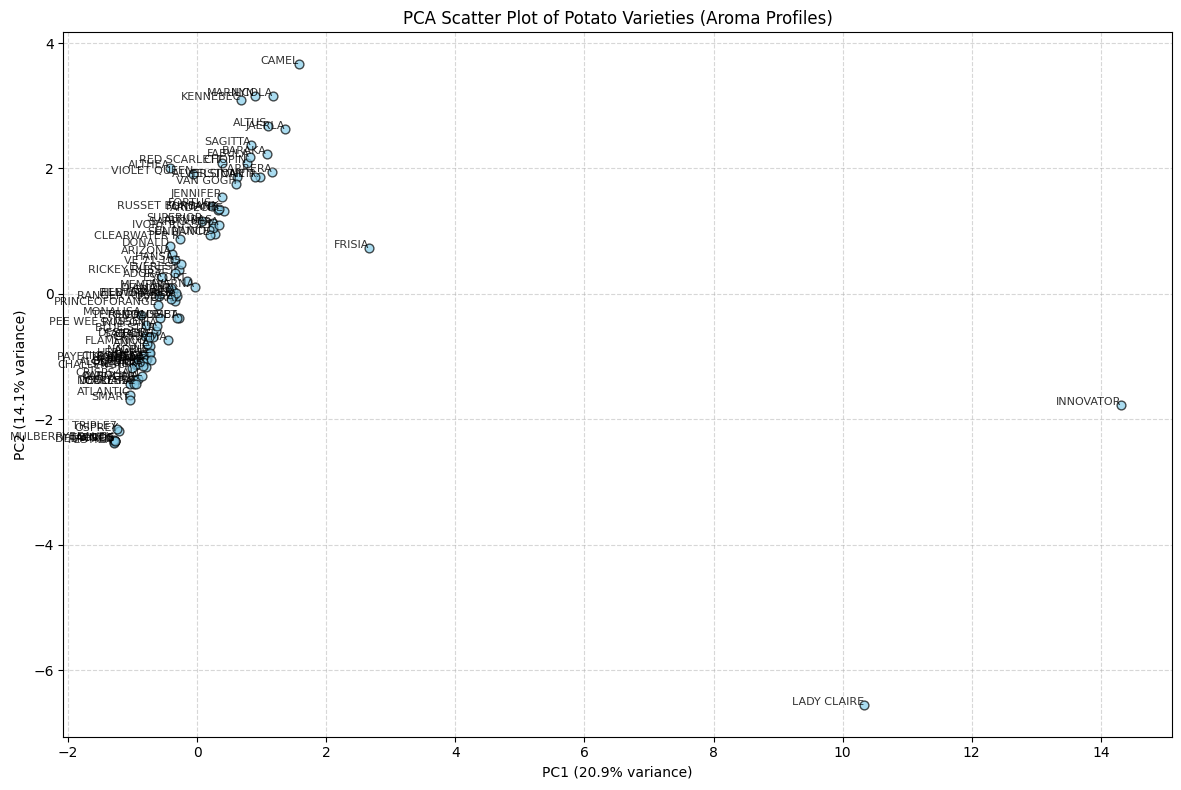

In [ ]:

X = aroma_pivot_renamed.drop(columns=["Variety"], errors="ignore")
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
scores_array = pca.fit_transform(X_scaled)

scores = pd.DataFrame(scores_array, columns=["PC1","PC2"], index=aroma_pivot_renamed.index)
scores["Variety"] = aroma_pivot_renamed["Variety"].values

loadings = pd.DataFrame(pca.components_.T, 
                        columns=["PC1","PC2"], 
                        index=X.columns)


plt.figure(figsize=(12,8))

# Scatter all varieties
plt.scatter(scores["PC1"], scores["PC2"], s=40, alpha=0.7, color="skyblue", edgecolor="k")

# Add labels for each variety
for _, row in scores.iterrows():
    plt.text(row["PC1"], row["PC2"], row["Variety"],
             fontsize=8, alpha=0.8, ha='right')

# Labels and title
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA Scatter Plot of Potato Varieties (Aroma Profiles)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


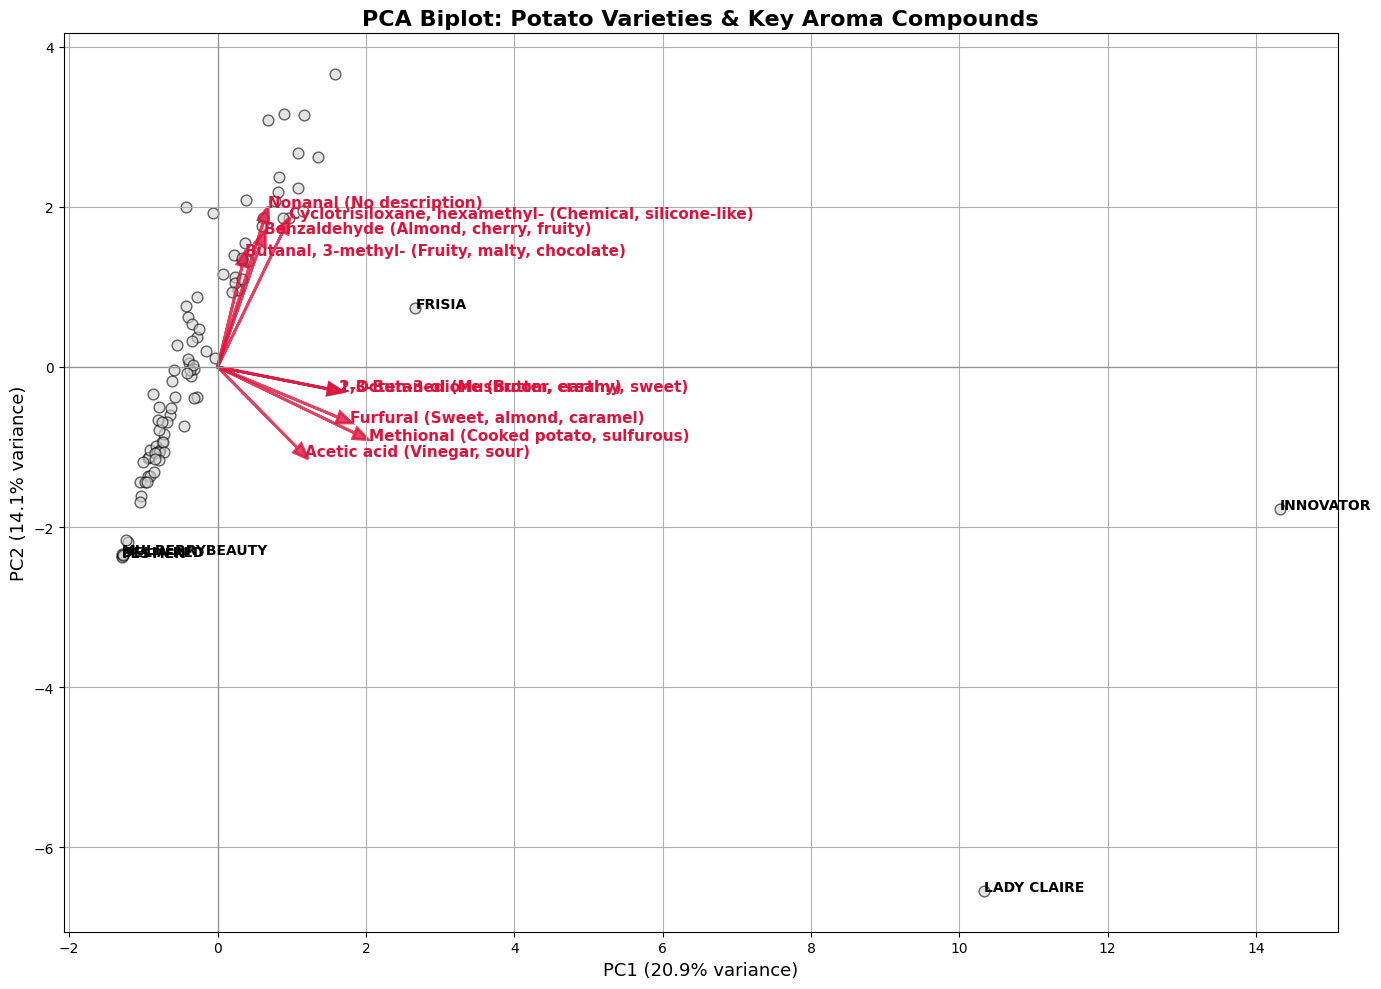

In [ ]:


top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(5).index
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(5).index
top_compounds = list(set(top_pc1) | set(top_pc2))

plt.figure(figsize=(14,10))

# Variety scatter
plt.scatter(scores["PC1"], scores["PC2"], 
            s=60, alpha=0.6, color="lightgrey", edgecolor="k")

# Label a few extreme varieties (برای readability)
for _, row in scores.nlargest(3,"PC1").iterrows():
    plt.text(row["PC1"], row["PC2"], row["Variety"], fontsize=10, fontweight="bold")
for _, row in scores.nsmallest(3,"PC1").iterrows():
    plt.text(row["PC1"], row["PC2"], row["Variety"], fontsize=10, fontweight="bold")

# Loadings arrows
scaling_factor = 4
for compound in top_compounds:
    x = loadings.loc[compound, "PC1"] * scaling_factor
    y = loadings.loc[compound, "PC2"] * scaling_factor
    plt.arrow(0, 0, x, y, color="crimson", alpha=0.8, 
              head_width=0.15, head_length=0.2, linewidth=2)
    plt.text(x*1.1, y*1.1, compound, color="crimson", fontsize=11, fontweight="bold")

# Labels
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=13)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=13)
plt.title("PCA Biplot: Potato Varieties & Key Aroma Compounds", fontsize=16, fontweight="bold")

# Styling
plt.axhline(0, color='grey', lw=1, alpha=0.6)
plt.axvline(0, color='grey', lw=1, alpha=0.6)
plt.grid("False")
plt.tight_layout()
plt.show()


Clustering Potato Varieties by Aroma Profiles using PCA, K-Means, and DBSCAN

k=2, silhouette=0.766
k=3, silhouette=0.758
k=4, silhouette=0.353
k=5, silhouette=0.363
k=6, silhouette=0.365
Best k=2 (silhouette=0.766)


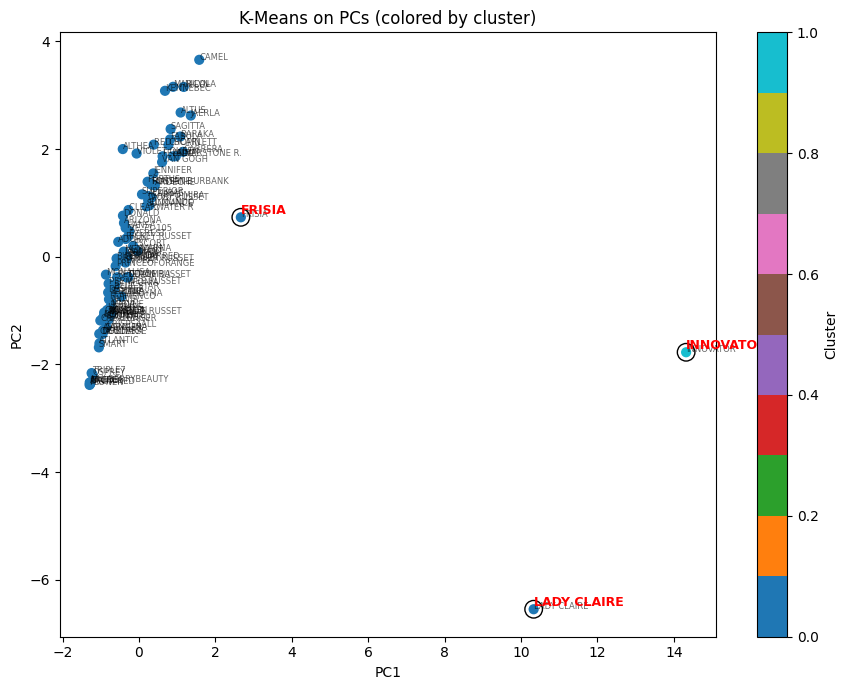


=== DBSCAN cluster membership ===
Cluster -1: 57 varieties
  (outliers)
   ['ADORA', 'ALTHEA', 'ALTURAS', 'ALTUS', 'ALVERSTONE R.', 'ANTI', 'ARDECHE', 'ARIZONA', 'ATLANTIC', 'AVARNA', 'BARAKA', 'BILDTSTAR', 'CAMEL', 'CARRERA', 'CHOPIN'] ...
Cluster 0: 22 varieties
   ['AGRIA', 'ALOUETTE', 'AVENGER', 'BERBER', 'BLUE STAR', 'CARLITA', 'CAROLINA', 'CECILE', 'CHALLENGER', 'CIKLAMEN', 'CRISPS4ALL', 'DEODARA', 'HERMES', 'KONDOR', 'MUSE'] ...
Cluster 1: 3 varieties
   ['ANIVIA', 'CARDYMA', 'SYMFONIA'] 
Cluster 2: 9 varieties
   ['ARGOS', 'BINTJE', 'DELIA RED', 'FESTIEN', 'MULBERRYBEAUTY', 'OSPREY', 'SMART', 'TAURUS', 'TRIPLE7'] 
Cluster 3: 3 varieties
   ['COLOMBA', 'MEMPHIS', 'REDDALE'] 


In [ ]:

# keep only numeric columns for PCA 
X = aroma_pivot_renamed.select_dtypes(include=[np.number])

# scale numeric data
Xz = StandardScaler().fit_transform(X.values)

# PCA to reduce dimensionality
pcs = PCA(n_components=6, random_state=0).fit_transform(Xz)

# KMeans with silhouette
best_k, best_s, best_labels = None, -1, None
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=20, random_state=0).fit(pcs)
    s = silhouette_score(pcs, km.labels_)
    print(f'k={k}, silhouette={s:.3f}')
    if s > best_s:
        best_k, best_s, best_labels = k, s, km.labels_

print(f'Best k={best_k} (silhouette={best_s:.3f})')

# Plot KMeans on PC1 & PC2 
scores_2d = pcs[:, :2]
plt.figure(figsize=(9,7))
sc = plt.scatter(scores_2d[:,0], scores_2d[:,1], c=best_labels, s=40, cmap="tab10")
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('K-Means on PCs (colored by cluster)')
plt.colorbar(sc, label='Cluster')

# Label all varieties
if "Variety" in aroma_pivot_renamed.columns:
    names = aroma_pivot_renamed["Variety"].astype(str).values
else:
    names = aroma_pivot_renamed.index.astype(str).to_list()

for i, name in enumerate(names):
    plt.text(scores_2d[i,0], scores_2d[i,1], str(name),
             fontsize=6, alpha=0.6)

# Highlight outlier varieties
focus = {'INNOVATOR','LADY CLAIRE','FRISIA'}
for i, name in enumerate(names):
    if str(name).upper() in focus:
        plt.scatter(scores_2d[i,0], scores_2d[i,1], s=160, edgecolor='k', facecolor='none')
        plt.text(scores_2d[i,0], scores_2d[i,1], name, fontsize=9, weight='bold',
                 ha='left', va='bottom', color='red')

plt.tight_layout()
plt.show()

#  DBSCAN clustering
db = DBSCAN(eps=0.7, min_samples=3).fit(pcs)
labels_db = db.labels_

print('\n=== DBSCAN cluster membership ===')
for cluster in np.unique(labels_db):
    members = [names[i] for i in np.where(labels_db == cluster)[0]]
    print(f"Cluster {cluster}: {len(members)} varieties")
    if cluster == -1:
        print("  (outliers)")
    print("  ", members[:15], "..." if len(members) > 15 else "")



# Checking the optimum cluster

In [ ]:

X_pca = PCA(n_components=6, random_state=0).fit_transform(Xz)

results = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_pca)
    labels = kmeans.labels_
    
    sil = silhouette_score(X_pca, labels)
    dbi = davies_bouldin_score(X_pca, labels)
    chi = calinski_harabasz_score(X_pca, labels)
    
    results.append((k, sil, dbi, chi))

for k, sil, dbi, chi in results:
    print(f"k={k}, silhouette={sil:.3f}, DBI={dbi:.3f}, CHI={chi:.3f}")

k=2, silhouette=0.350, DBI=1.615, CHI=20.126
k=3, silhouette=0.329, DBI=1.478, CHI=17.083
k=4, silhouette=0.343, DBI=1.110, CHI=26.189
k=5, silhouette=0.363, DBI=0.755, CHI=48.038
k=6, silhouette=0.365, DBI=0.822, CHI=46.795


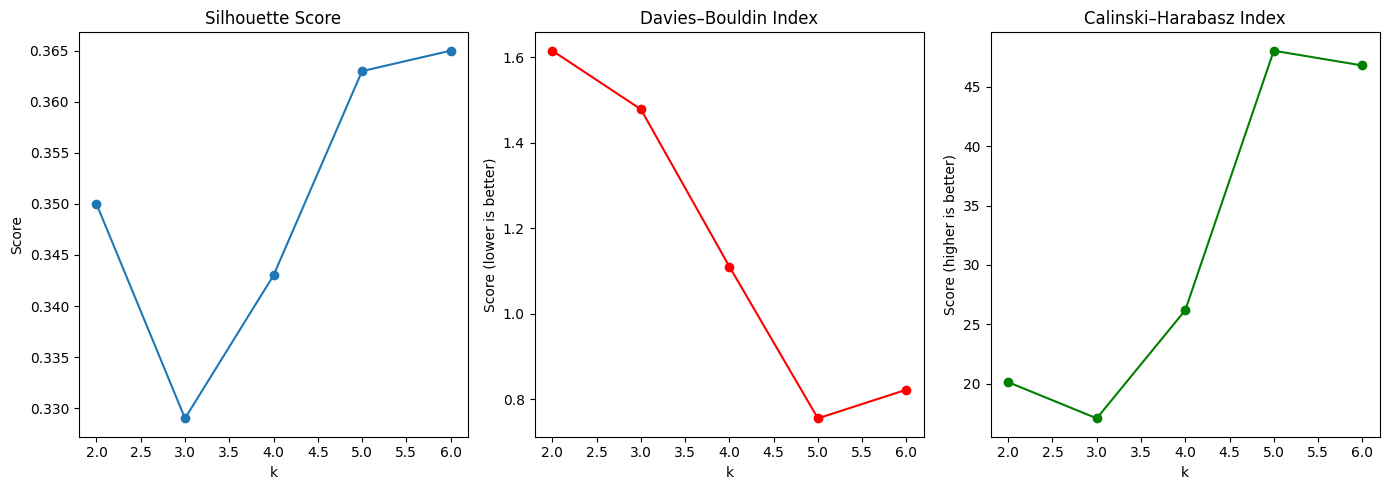

In [ ]:


# Store results in lists for plotting
k_values = [2, 3, 4, 5, 6]
sil_scores = [0.350, 0.329,0.343, 0.363, 0.365]
dbi_scores = [1.615, 1.478,1.110, 0.755, 0.822]
chi_scores = [20.126, 17.083, 26.189, 48.038, 46.795]

plt.figure(figsize=(14,5))

# Silhouette
plt.subplot(1,3,1)
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Score")

# Davies-Bouldin
plt.subplot(1,3,2)
plt.plot(k_values, dbi_scores, marker='o', color='red')
plt.title("Davies–Bouldin Index")
plt.xlabel("k")
plt.ylabel("Score (lower is better)")

# Calinski–Harabasz
plt.subplot(1,3,3)
plt.plot(k_values, chi_scores, marker='o', color='green')
plt.title("Calinski–Harabasz Index")
plt.xlabel("k")
plt.ylabel("Score (higher is better)")

plt.tight_layout()
plt.show()


the reults and plot shows the optimal cluster number for aroma dataset  is k=6.

# 3D PCA Clustering of Potato Varieties (K-Means, k=6) with DBSCAN Outlier Detection

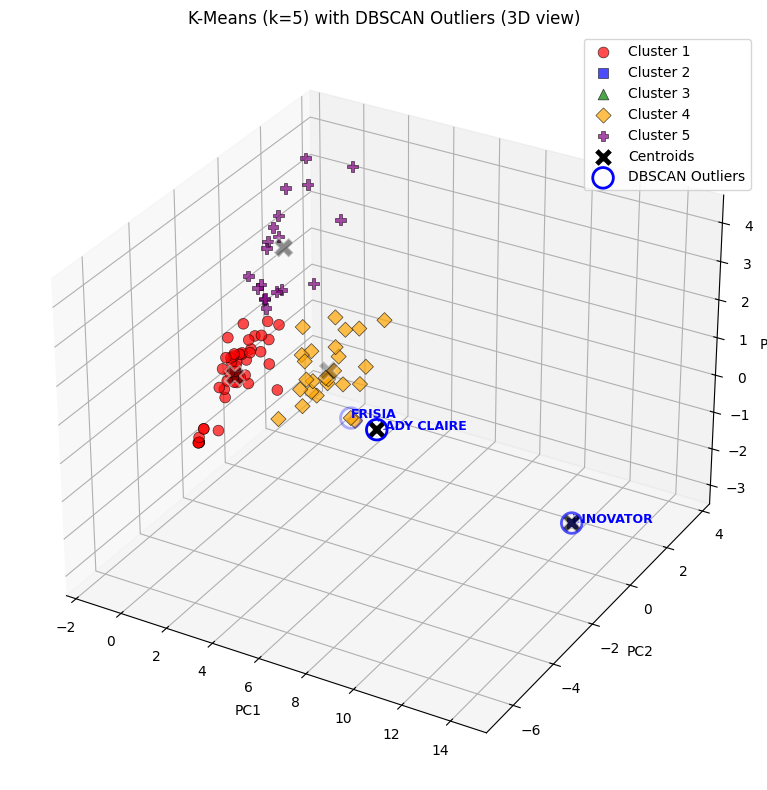


=== DBSCAN Outlier Varieties ===
FRISIA
INNOVATOR
LADY CLAIRE


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from mpl_toolkits.mplot3d import Axes3D

# --- تنظیمات KMeans با k=5 ---
k_best =5
km = KMeans(n_clusters=k_best, n_init=20, random_state=0).fit(pcs)
labels_k5 = km.labels_
centroids = km.cluster_centers_[:, :3]  # استفاده از 3 مولفه اصلی اول

# --- تنظیمات DBSCAN برای تشخیص پرت (Outlier Detection) ---
# پارامترهای به‌روز شده برای کاهش پرت‌ها
db = DBSCAN(eps=1.7, min_samples=3).fit(pcs[:, :3])
outliers = np.where(db.labels_ == -1)[0]

# 3D Plot - Visualizing K-Means Clusters and DBSCAN Outliers
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'blue', 'green', 'orange', 'purple']
markers = ['o', 's', '^', 'D', 'P']

# 1. Plot each KMeans cluster
for cluster in range(k_best):
    cluster_points = pcs[labels_k5 == cluster, :3]
    ax.scatter(cluster_points[:,0], cluster_points[:,1], cluster_points[:,2],
               s=60, color=colors[cluster], marker=markers[cluster],
               alpha=0.7, edgecolor='k', linewidth=0.5,
               label=f'Cluster {cluster+1}')

# 2. Plot centroids
ax.scatter(centroids[:,0], centroids[:,1], centroids[:,2],
           marker='X', s=200, c='black', edgecolor='white',
           linewidth=1.5, label='Centroids')

# 3. Define names for labeling outliers
if "Variety" in aroma_pivot_renamed.columns:
    names = aroma_pivot_renamed["Variety"].values
else:
    names = aroma_pivot_renamed.index.to_list()

# 4. Highlight DBSCAN outliers + add names (استفاده از لیست 'outliers' به‌روز شده)
ax.scatter(pcs[outliers,0], pcs[outliers,1], pcs[outliers,2],
           s=220, facecolor='none', edgecolor='blue', linewidth=2,
           label='DBSCAN Outliers')

for i in outliers:
    ax.text(pcs[i,0], pcs[i,1], pcs[i,2],
            str(names[i]), color='blue', fontsize=9, weight='bold')

# 5. Set labels and title
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("K-Means (k=5) with DBSCAN Outliers (3D view)")
ax.legend()
plt.tight_layout()
plt.show()

# 6. Print final outlier names
print("\n=== DBSCAN Outlier Varieties ===")
for i in outliers:
    print(f"{names[i]}")

Nonanal (Waxy, citrus, rose) → Outliers have a much higher mean intensity compared to the normal varieties → this compound is likely a key driver in separating the outliers.

Methyl butanoate (Fruity, apple, sweet) and Decanal (Citrus, floral) → also show significantly higher intensities in outliers.

Cyclotrisiloxane (a silicone-related artefact) is stronger in outliers too, which could reflect noise or special sampling conditions.

Other compounds such as Benzaldehyde and Octanal show smaller differences, but still seem slightly enriched in some outlier varieties.

#  Statistics of aroma intensities per variety

In [ ]:
# Calculate mean and std of each compound across varieties
desc_stats =aroma_pivot_renamed.describe().T  # transpose to have compounds as rows

# Show top compounds with highest mean intensity overall
top_compounds = desc_stats.sort_values(by='mean', ascending=False).head(10)
print("Top 10 aroma compounds by average intensity:")
print(top_compounds[['mean', 'std']])
aroma_pivot_renamed.shape


Top 10 aroma compounds by average intensity:
                                                            mean           std
Nonanal (No description)                            1.568049e+07  7.812851e+06
2-Propanone, 1-methoxy- (Solvent, chemical)         4.654142e+06  6.436208e+06
Cyclotrisiloxane, hexamethyl- (Chemical, silico...  3.601464e+06  3.033010e+06
Decanal (Citrus, floral)                            2.783173e+06  2.830299e+06
Butanal, 3-methyl- (Fruity, malty, chocolate)       2.384541e+06  1.882418e+06
Hexanal (Green, grassy)                             1.827816e+06  3.724235e+06
Benzaldehyde (Almond, cherry, fruity)               9.457570e+05  1.416821e+06
Octanal (Citrus, fruity)                            9.433440e+05  7.080811e+05
Dimethyl trisulfide (Garlic, onion, sulfurous)      5.814366e+05  7.421971e+05
Pentanal (Green, fatty, pungent)                    4.010920e+05  1.053359e+06


(94, 20)

The table shows the 10 aroma compounds with the highest mean intensity across all potato varieties, along with their standard deviation, indicating variability between varieties. Nonanal, 2-Propanone, 1-methoxy-, and Cyclotrisiloxane, hexamethyl- are the most abundant compounds overall

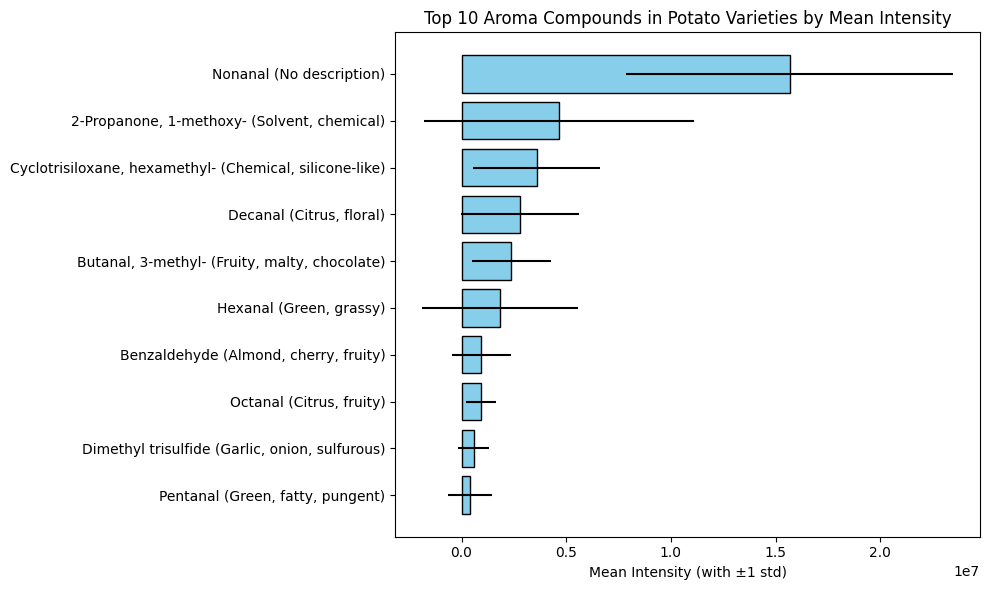

In [ ]:

# Calculate mean and std of each compound across varieties
desc_stats = aroma_pivot_renamed.describe().T  

# Get top 10 compounds by mean intensity
top_compounds = desc_stats.sort_values(by='mean', ascending=False).head(10)
top_compounds_plot = top_compounds[['mean', 'std']]

# Bar plot with error bars 
plt.figure(figsize=(10,6))
plt.barh(
    top_compounds_plot.index,
    top_compounds_plot['mean'],
    xerr=top_compounds_plot['std'],
    color='skyblue',
    edgecolor='black'
)

plt.xlabel("Mean Intensity (with ±1 std)")
plt.title("Top 10 Aroma Compounds in Potato Varieties by Mean Intensity")
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()


# Hierarchical Clustering of Potato Varieties Based on Aroma Profiles (DBSCAN Outliers Highlighted)

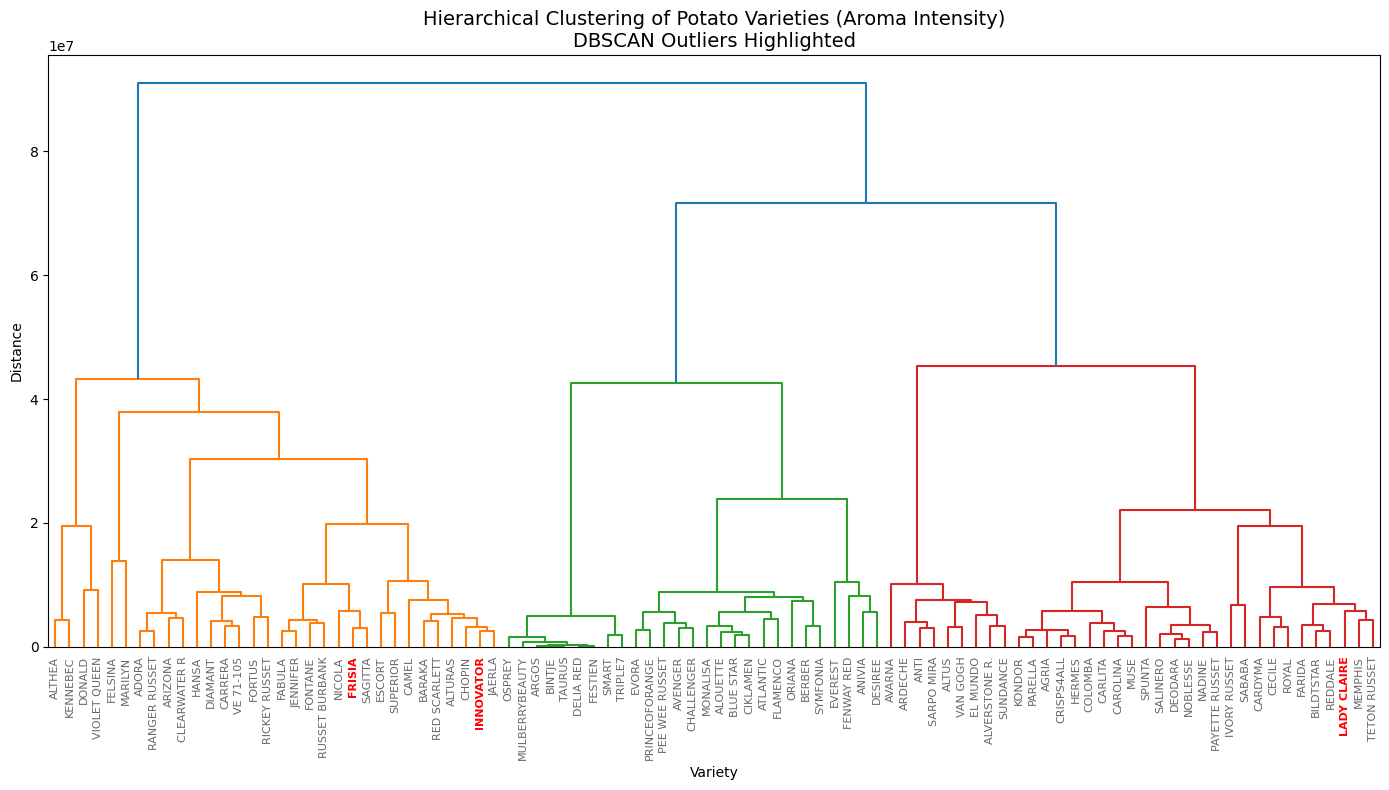

In [ ]:

# Outliers found with DBSCAN
focus_outliers = {"FRISIA", "INNOVATOR", "LADY CLAIRE"}

# select only numeric columns for clustering
X = aroma_pivot_renamed.select_dtypes(include=[np.number])

# linkage
Z = linkage(X, method='ward')

# use variety names as labels
labels = aroma_pivot_renamed["Variety"].values if "Variety" in aroma_pivot_renamed.columns else aroma_pivot_renamed.index

# dendrogram
plt.figure(figsize=(14, 8))
dend = dendrogram(
    Z,
    labels=labels,
    leaf_rotation=90,
    leaf_font_size=8
)

# Highlight DBSCAN outliers
ax = plt.gca()
x_labels = ax.get_xmajorticklabels()
for lbl in x_labels:
    if lbl.get_text().upper() in focus_outliers:
        lbl.set_color("red")
        lbl.set_fontweight("bold")
    else:
        lbl.set_alpha(0.6)

plt.title("Hierarchical Clustering of Potato Varieties (Aroma Intensity)\nDBSCAN Outliers Highlighted", fontsize=14)
plt.xlabel("Variety")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


The dendrogram shows that while most varieties cluster tightly into 3–4 main aroma groups, CARRERA, FRISIA, INNOVATOR, KENNEBEC, and LADY CLAIRE stand out as aroma outliers.
They are still related to other clusters but only at large distances.

# Contribution of compounds in aroma

In [ ]:


if "Variety" in aroma_pivot_renamed.columns:
    BASE_REL = aroma_pivot_renamed.set_index("Variety").copy()
else:
    BASE_REL = aroma_pivot_renamed.copy()

# Ensure everything is string-labeled
BASE_REL.index = BASE_REL.index.astype(str)
BASE_REL.columns = [str(c) for c in BASE_REL.columns]

# Dropdown options
variety_options = [{"label": v, "value": v} for v in BASE_REL.index]

app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Potato Aroma Compound Dashboard"),

    html.Label("Select Variety:"),
    dcc.Dropdown(
        id="variety-dropdown",
        options=variety_options,
        value=BASE_REL.index[0],   # default = first variety
        clearable=False
    ),

    dcc.Graph(id="compound-barplot"),
    dcc.Graph(id="compound-heatmap"),
])

# Callbacks
@app.callback(
    [Output("compound-barplot", "figure"),
     Output("compound-heatmap", "figure")],
    [Input("variety-dropdown", "value")]
)
def update_dashboard(selected_variety):
    # Extract data for selected variety
    s = BASE_REL.loc[selected_variety]

    # Force numeric values
    s = pd.to_numeric(s, errors="coerce").fillna(0)

    # Sort compounds by intensity
    s = s.sort_values(ascending=False).reset_index()
    s.columns = ["Compound", "Relative Concentration"]

    # Bar Plot 
    fig_bar = px.bar(
        s, x="Compound", y="Relative Concentration",
        title=f"Aroma Profile for {selected_variety}",
        color="Relative Concentration",
        color_continuous_scale="Blues"
    )
    fig_bar.update_layout(
        xaxis_tickangle=-45,
        height=450,
        margin=dict(l=60, r=20, t=60, b=120)
    )

    # Heatmap (all varieties × compounds) 
    heat_df = BASE_REL.apply(pd.to_numeric, errors="coerce").fillna(0).T
    fig_heat = px.imshow(
        heat_df, aspect="auto", color_continuous_scale="Viridis",
        labels={"x": "Variety", "y": "Compound", "color": "Relative Conc."},
        title="Heatmap of Compounds Across Varieties"
    )
    fig_heat.update_layout(
        height=600,
        margin=dict(l=90, r=20, t=60, b=120)
    )

    return fig_bar, fig_heat

if __name__ == "__main__":
    app.run(debug=True, port=8057)


   index   Variety  1-Nonanol (Floral, waxy)  1-Octen-3-ol (Mushroom, earthy)  \
0      0     ADORA                       0.0                              0.0   
1      1     AGRIA                       0.0                              0.0   
2      2  ALOUETTE                       0.0                              0.0   
3      3    ALTHEA                       0.0                              0.0   
4      4   ALTURAS                       0.0                              0.0   

   2,3-Butanedione (Butter, creamy, sweet)  \
0                                      0.0   
1                                      0.0   
2                                      0.0   
3                                      0.0   
4                                      0.0   

   2-Propanone, 1-methoxy- (Solvent, chemical)  Acetic acid (Vinegar, sour)  \
0                                 0.000000e+00                          0.0   
1                                 8.736707e+06                          0.0   

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_1840\3398805649.py:24: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



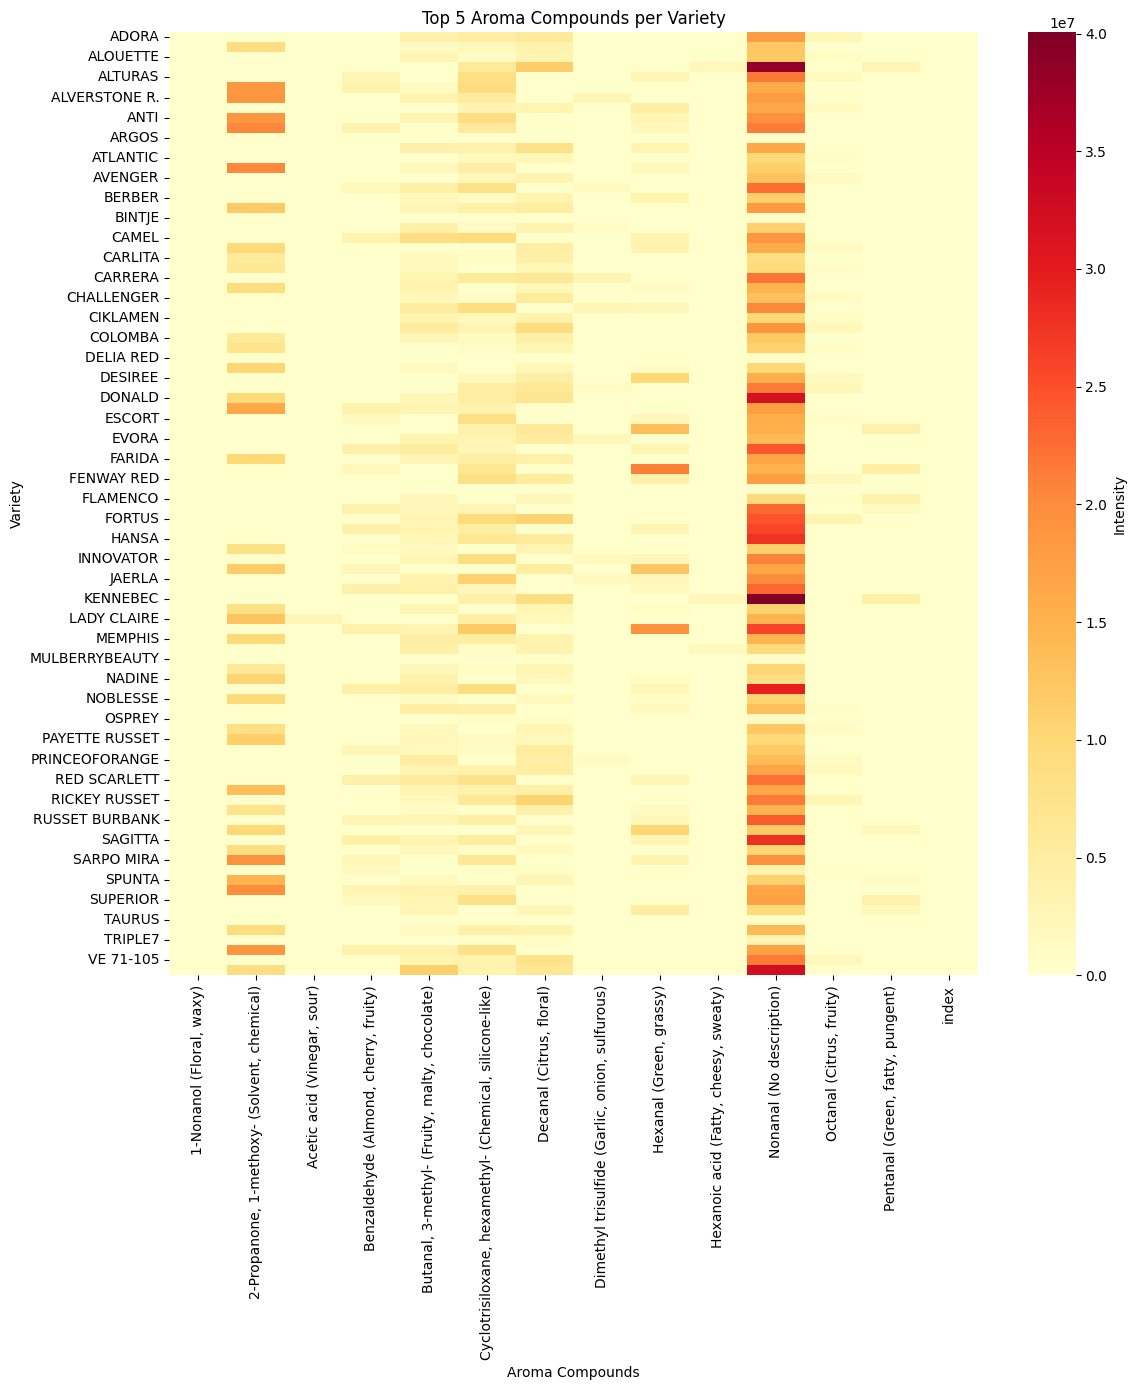

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # (Assuming you might need this for other operations)

# 1. Prepare data (Assuming 'aroma_pivot_renamed' is loaded)
aroma_df = aroma_pivot_renamed.reset_index()
# aroma_df.to_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\aroma_df.csv', index=False)
print(aroma_df.head())


# Step 1: Convert Wide → Long (Melting the data)
aroma_long = aroma_df.melt(
    id_vars="Variety",
    var_name="Compound",
    value_name="Intensity"
)

# Step 2: Get Top 5 Compounds for each Variety
# FIX: Use group_keys=False to prevent the creation of a MultiIndex,
# which causes the numeric indices to show up when reset_index is called later.
top_aromas = (
    aroma_long.groupby("Variety", group_keys=False) # <--- CRITICAL FIX
    .apply(lambda g: g.nlargest(5, "Intensity"))
    .reset_index(drop=True)
)

# Step 3: Pivot for the Heatmap
# 'Variety' is now correctly used as the row index for the heatmap
heatmap_data = top_aromas.pivot_table(
    index="Variety",
    columns="Compound",
    values="Intensity",
    fill_value=0
)

# Step 4: Plot the Heatmap
plt.figure(figsize=(12, 14))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    cbar_kws={'label': 'Intensity'}
)
plt.title("Top 5 Aroma Compounds per Variety")
plt.ylabel("Variety")
plt.xlabel("Aroma Compounds")
plt.tight_layout()
plt.show()

# Joining the sensory panel data 

In [ ]:
sensory = pd.read_excel(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx")
print(sensory.columns)
sensory.head()

Index(['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour',
       'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness',
       'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes',
       'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma',
       'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh',
       'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour',
       'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour',
       'Sweet Flavour', 'Root/ Vegetable Flavour',
       'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel',
       'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh',
       'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin',
       'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste',
       'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47',
       'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK',
       'cluster 3 Sp, clu

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Cleaning of sensory dataset 

In [ ]:
# flavor-related columns
FLAVOR_COLS = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste", 'Earthy Aroma',
    'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Potato Starch','Metalic'
]


sensory['VARIETY'] = sensory['VARIETY'].astype(str).str.strip()

# Drop any unnamed columns
sensory = sensory.drop(columns=[c for c in sensory.columns if str(c).startswith('Unnamed')], errors='ignore')

#  Coerce numerics & groupby mean per variety 
sensory_traits = sensory[FLAVOR_COLS].apply(pd.to_numeric, errors='coerce')
sensory_traits = sensory_traits.assign(VARIETY=sensory['VARIETY'])

sensory_summary = (
    sensory_traits
    .groupby('VARIETY', as_index=False)
    .mean(numeric_only=True)
)

print("Rows (varieties):", sensory_summary['VARIETY'].nunique())
print("Traits averaged:", len(FLAVOR_COLS))
print("First rows:")
print(sensory_summary.head())


Rows (varieties): 59
Traits averaged: 22
First rows:
  VARIETY  Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0   ADORA            17.627          15.329          26.573        10.678   
1   AGATA            10.171          11.633          18.378         7.548   
2   AGRIA             8.018           5.872          20.421         3.787   
3   AMBRA            11.192          12.155          20.334         7.135   
4  AMPERA            13.018          11.176          20.486        11.591   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0         24.014          3.098                   17.360   
1         30.340          3.250                   10.600   
2         29.188          1.859                   13.447   
3         33.122          2.729                   17.447   
4         24.644          3.511                   15.991   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  ...  Earthy Aroma  \
0                        12.520             15.647

# Predicting the flavors for all the non existing varaieties by using the aroma compounds

# First merge aroma and sensory datasets

In [ ]:
aroma_df = aroma_pivot_renamed.reset_index()
aroma_df.to_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\aroma_df.csv', index=False)

# Drop extra index columns if they exist
cols_to_drop = [c for c in ["level_0", "index"] if c in sensory_summary.columns]
sensory_summary = sensory_summary.drop(columns=cols_to_drop)

# Rename the correct variety column
sensory_summary = sensory_summary.rename(columns={"VARIETY": "Variety"})

# Standardize Variety
sensory_summary["Variety"] = sensory_summary["Variety"].astype(str).str.strip().str.upper()
aroma_df["Variety"] = aroma_df["Variety"].astype(str).str.strip().str.upper()

# Merge
merged_aroma_sensory = pd.merge(aroma_df, sensory_summary, on="Variety", how="inner")

print(f"Number of merged varieties: {merged_aroma_sensory['Variety'].nunique()}")
print(merged_aroma_sensory.head())



Number of merged varieties: 20
   index    Variety  1-Nonanol (Floral, waxy)  \
0      0      ADORA                       0.0   
1      1      AGRIA                       0.0   
2     16     BERBER                       0.0   
3     17  BILDTSTAR                       0.0   
4     18     BINTJE                       0.0   

   1-Octen-3-ol (Mushroom, earthy)  2,3-Butanedione (Butter, creamy, sweet)  \
0                              0.0                                      0.0   
1                              0.0                                      0.0   
2                              0.0                                      0.0   
3                              0.0                                      0.0   
4                              0.0                                      0.0   

   2-Propanone, 1-methoxy- (Solvent, chemical)  Acetic acid (Vinegar, sour)  \
0                                 0.000000e+00                          0.0   
1                                 8.73670

# predicting the sensory by aroma compounds using various models

# PLSR MOdel + MAF score

In [ ]:

# Sensory traits
sensory_cols =  [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste",'Intensity of Aroma', 'Earthy Aroma',
    'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh',
    'Intensity of Flavour', 'Potato Starch','Metalic'
]

compound_cols = [
    c for c in merged_aroma_sensory.columns 
    if c not in sensory_cols and c != "Variety"
]

# Training data (20 varieties with both aroma + sensory) 
X = merged_aroma_sensory[compound_cols]
Y = merged_aroma_sensory[sensory_cols]

# Standardize and fit PLSR 
scaler_X = StandardScaler()
scaler_Y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)

pls = PLSRegression(n_components=3)
pls.fit(X_scaled, Y_scaled)

# Predict sensory scores for all 94 varieties 
aroma_pivot_reset = aroma_pivot_renamed.reset_index()
all_X = aroma_pivot_reset[compound_cols]
all_X_scaled = scaler_X.transform(all_X)

predicted_Y_scaled = pls.predict(all_X_scaled)
predicted_Y = scaler_Y.inverse_transform(predicted_Y_scaled)

# Collect results into DataFrame 
predicted_df = pd.DataFrame(predicted_Y, columns=sensory_cols)

# Detect correct column for Variety
if "Variety" in aroma_pivot_reset.columns:
    predicted_df["Variety"] = aroma_pivot_reset["Variety"].values
elif "index" in aroma_pivot_reset.columns:
    predicted_df["Variety"] = aroma_pivot_reset["index"].values
else:
    raise ValueError("No Variety or index column found in aroma_pivot_reset!")

# Compute MAF (Mean Attribute Fraction / mean sensory intensity)
predicted_df["MAF_score"] = predicted_df[sensory_cols].mean(axis=1)

#  Results
print(predicted_df.head())

print("\nTop 10 strongest overall flavor varieties (highest MAF):")
print(predicted_df[["Variety","MAF_score"]].sort_values("MAF_score", ascending=False).head(10))


   Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0         11.425041       10.383883       21.042185      8.763024   
1          8.245530        7.276734       19.437433      4.870904   
2          9.184849        8.006844       18.685770      6.453444   
3          9.983378        9.204963       21.728422      6.502649   
4          8.679038        7.478633       17.271727      6.281209   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0      29.396324       3.672970                15.574711   
1      30.914703       2.528459                11.563462   
2      31.267653       4.091877                13.109927   
3      28.924737       1.666067                13.306918   
4      29.718255       4.260731                12.466037   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  Sour Aftertaste  ...  \
0                     10.846795          10.398438         9.974970  ...   
1                      7.887490           7.802730         5.354439  ...

In [ ]:

# Merge predictions with the measured sensory (20 varieties)
merged_results = pd.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],  # keep only Variety + measured traits
    predicted_df,
    on="Variety",
    suffixes=("_measured", "_predicted"),
    how="outer"   # keep all 94 varieties
)

merged_results.head()

,Variety,Metallic Flavour_measured,Bitter Flavour_measured,Earthy Flavour_measured,Sour Flavour_measured,Fresh Flavour_measured,Sweet Flavour_measured,Root/ Vegetable Flavour_measured,Farmyard (grass/hay) flavour_measured,Bitter Aftertaste_measured,...,Farmyard_predicted,Sweet_predicted,Starchy_predicted,Damp_predicted,Buttery_predicted,Fresh_predicted,Intensity of Flavour_predicted,Potato Starch_predicted,Metalic_predicted,MAF_score
0,ADORA,17.627,15.329,26.573,10.678,24.014,3.098,17.360,12.520,15.647,...,16.579308,5.548062,20.408708,17.295703,4.605608,30.908492,41.158191,28.967120,9.721840,16.888125
1,AGRIA,8.018,5.872,20.421,3.787,29.188,1.859,13.447,8.803,8.777,...,12.836751,4.239464,19.984765,15.611359,3.346614,30.485482,37.731867,32.964681,8.300335,15.206194
2,ALOUETTE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.541015,5.139160,19.309041,16.105765,4.106275,31.414156,39.648453,30.231374,7.547302,15.677045
3,ALTHEA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.127155,4.275727,21.110062,16.612724,3.502754,29.708257,38.484677,32.549309,10.530430,16.132765
4,ALTURAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.811162,4.473036,18.156378,16.668585,3.355124,31.225969,39.127237,29.173240,7.295811,15.138456


# Comparison of Measured vs Predicted Sensory Traits Using R² Evaluation


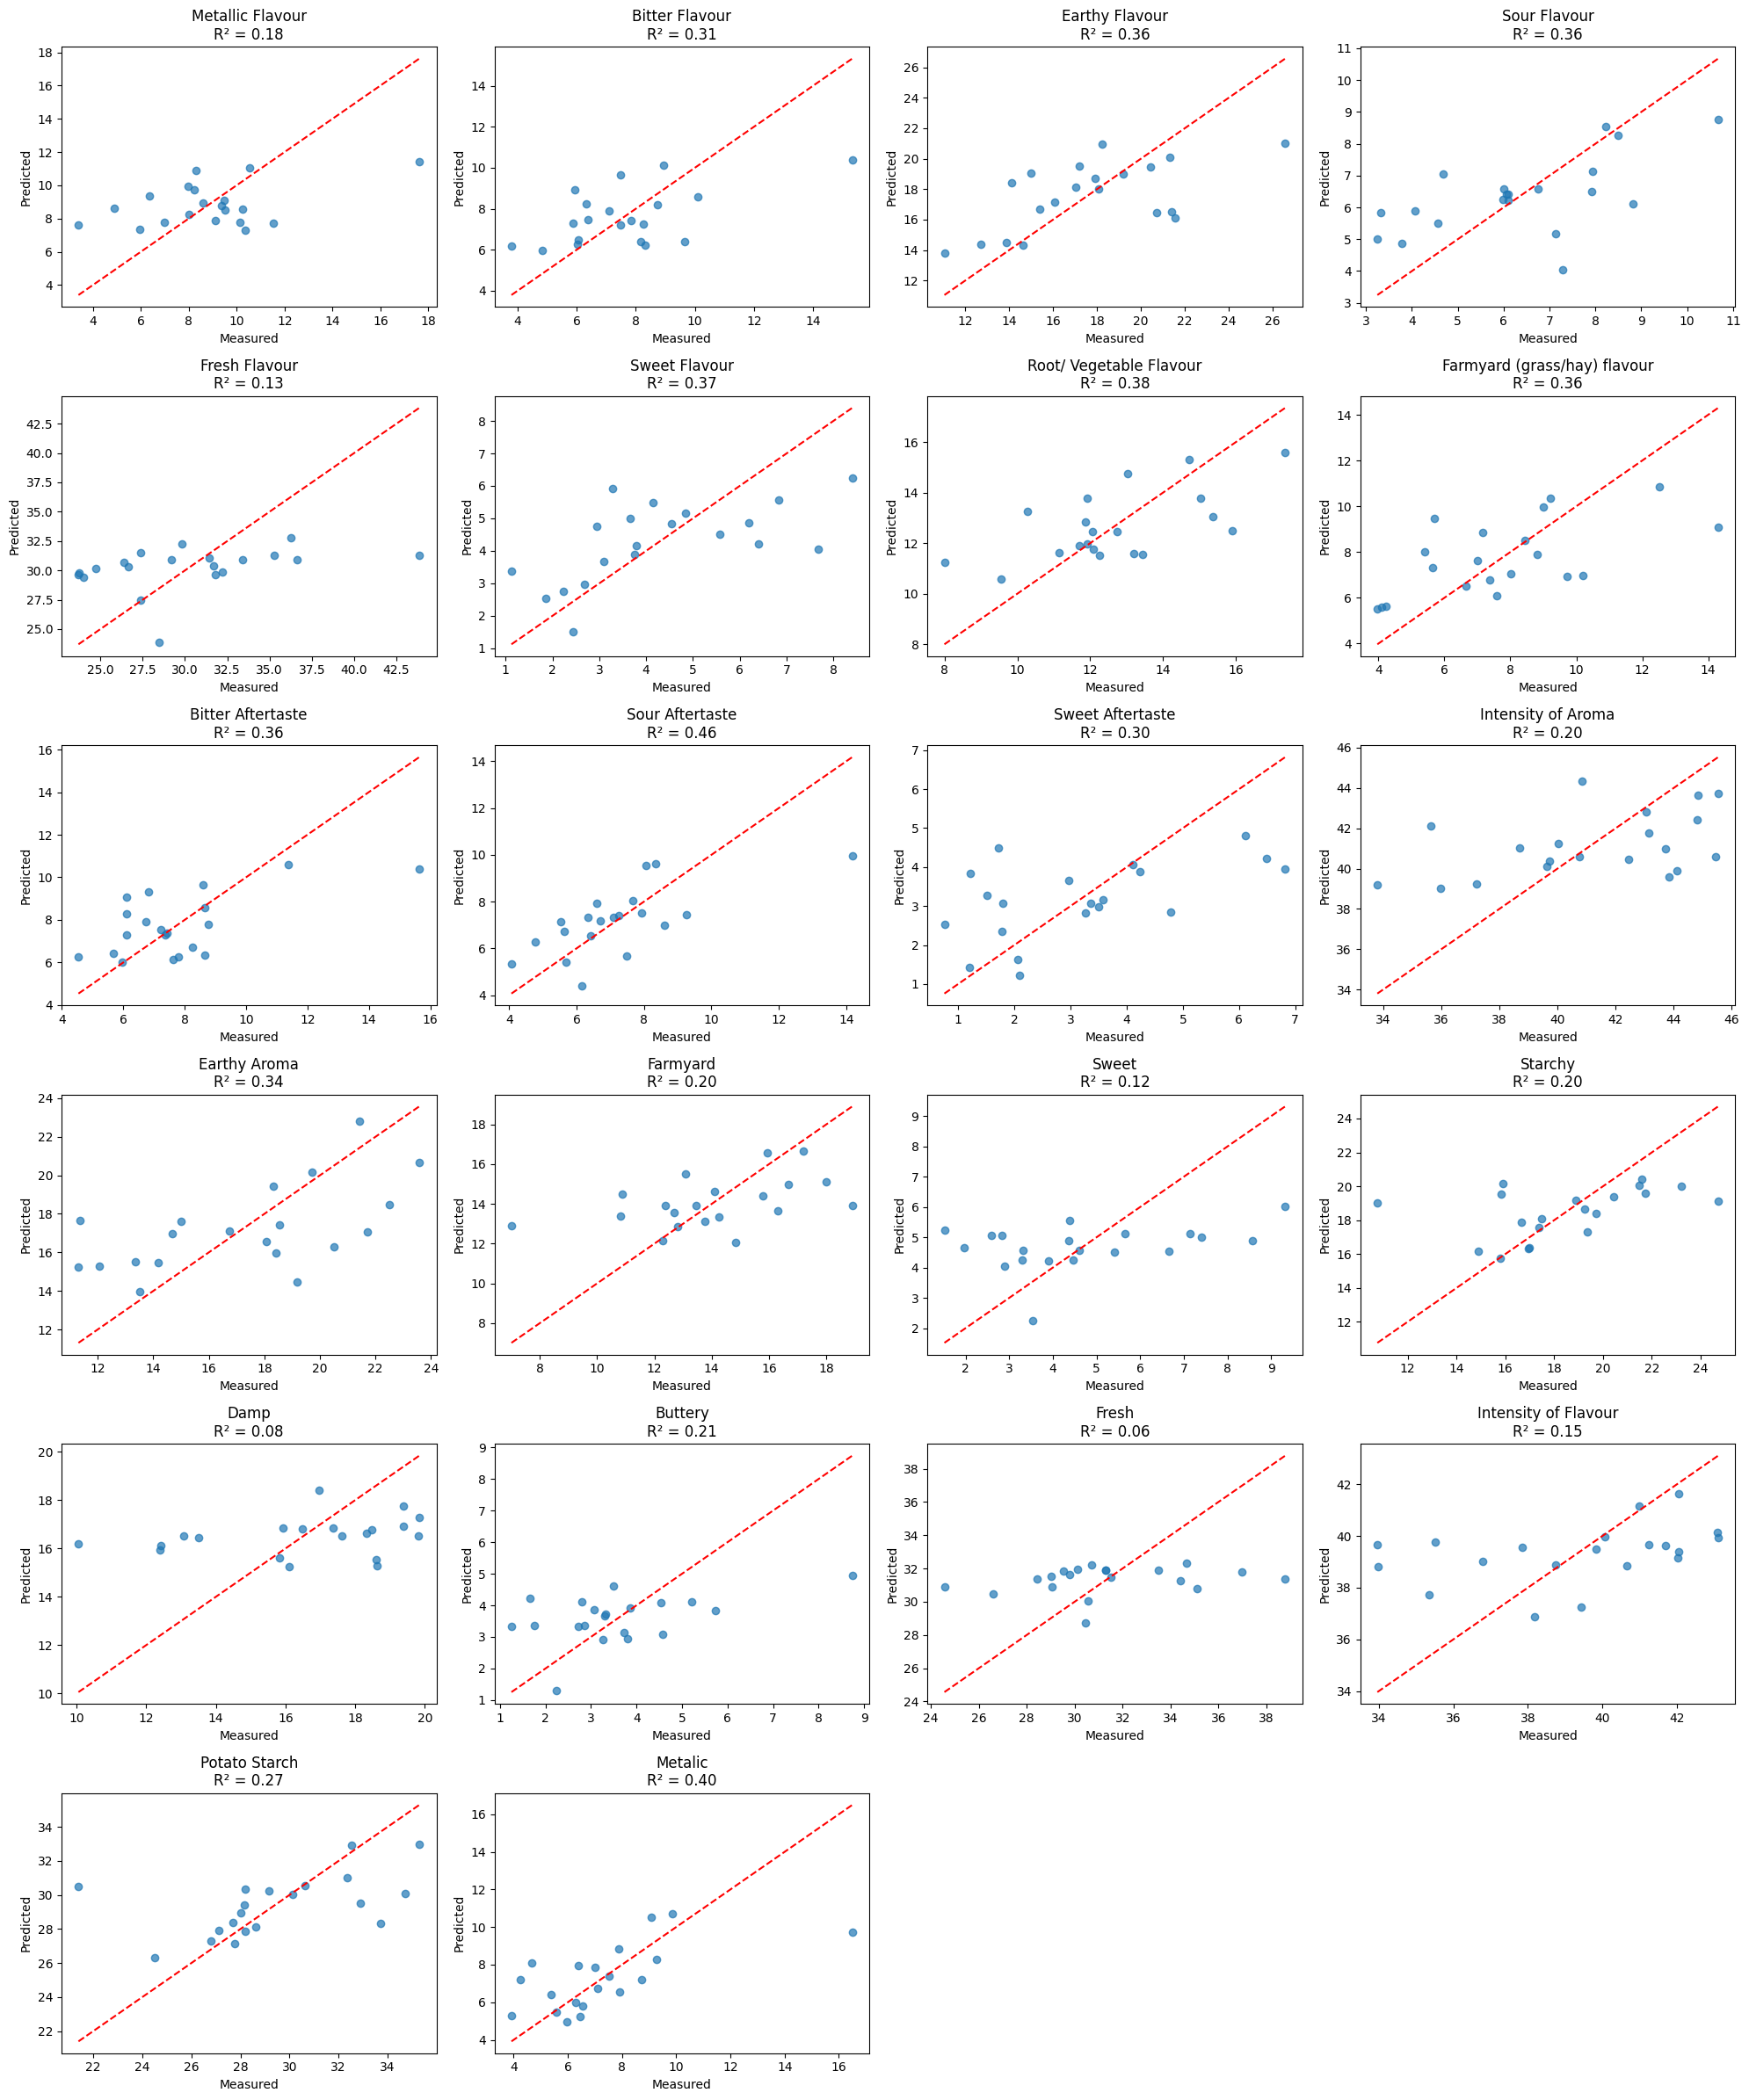

In [ ]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Mask for varieties with measured data
measured_mask = merged_results[sensory_cols[0] + "_measured"].notna()

n_traits = len(sensory_cols)
ncols = 4
nrows = (n_traits + ncols - 1) // ncols  # enough rows

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.ravel()

for i, trait in enumerate(sensory_cols):
    ax = axes[i]
    x = merged_results.loc[measured_mask, trait + "_measured"]
    y = merged_results.loc[measured_mask, trait + "_predicted"]
    
    ax.scatter(x, y, alpha=0.7)
    ax.plot([x.min(), x.max()], [x.min(), x.max()], "r--")
    
    r2 = r2_score(x, y)
    ax.set_title(f"{trait}\nR² = {r2:.2f}")
    ax.set_xlabel("Measured")
    ax.set_ylabel("Predicted")

# Hide unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


models are doing moderately well (R² ~ 0.3–0.4) for some traits but struggle with others but we should do cross validation to see the generalization of model.

# Random Forest Regressor


RandomForest - Top 10 Varieties:
         Variety  MAF_score
0          ADORA  17.101915
61      MONALISA  16.499804
11       ARIZONA  16.241110
7         ANIVIA  16.118277
29  CLEARWATER R  16.062865
34       DESIREE  16.013407
39       EVEREST  15.936858
4        ALTURAS  15.935138
35       DIAMANT  15.890636
24       CARRERA  15.779608


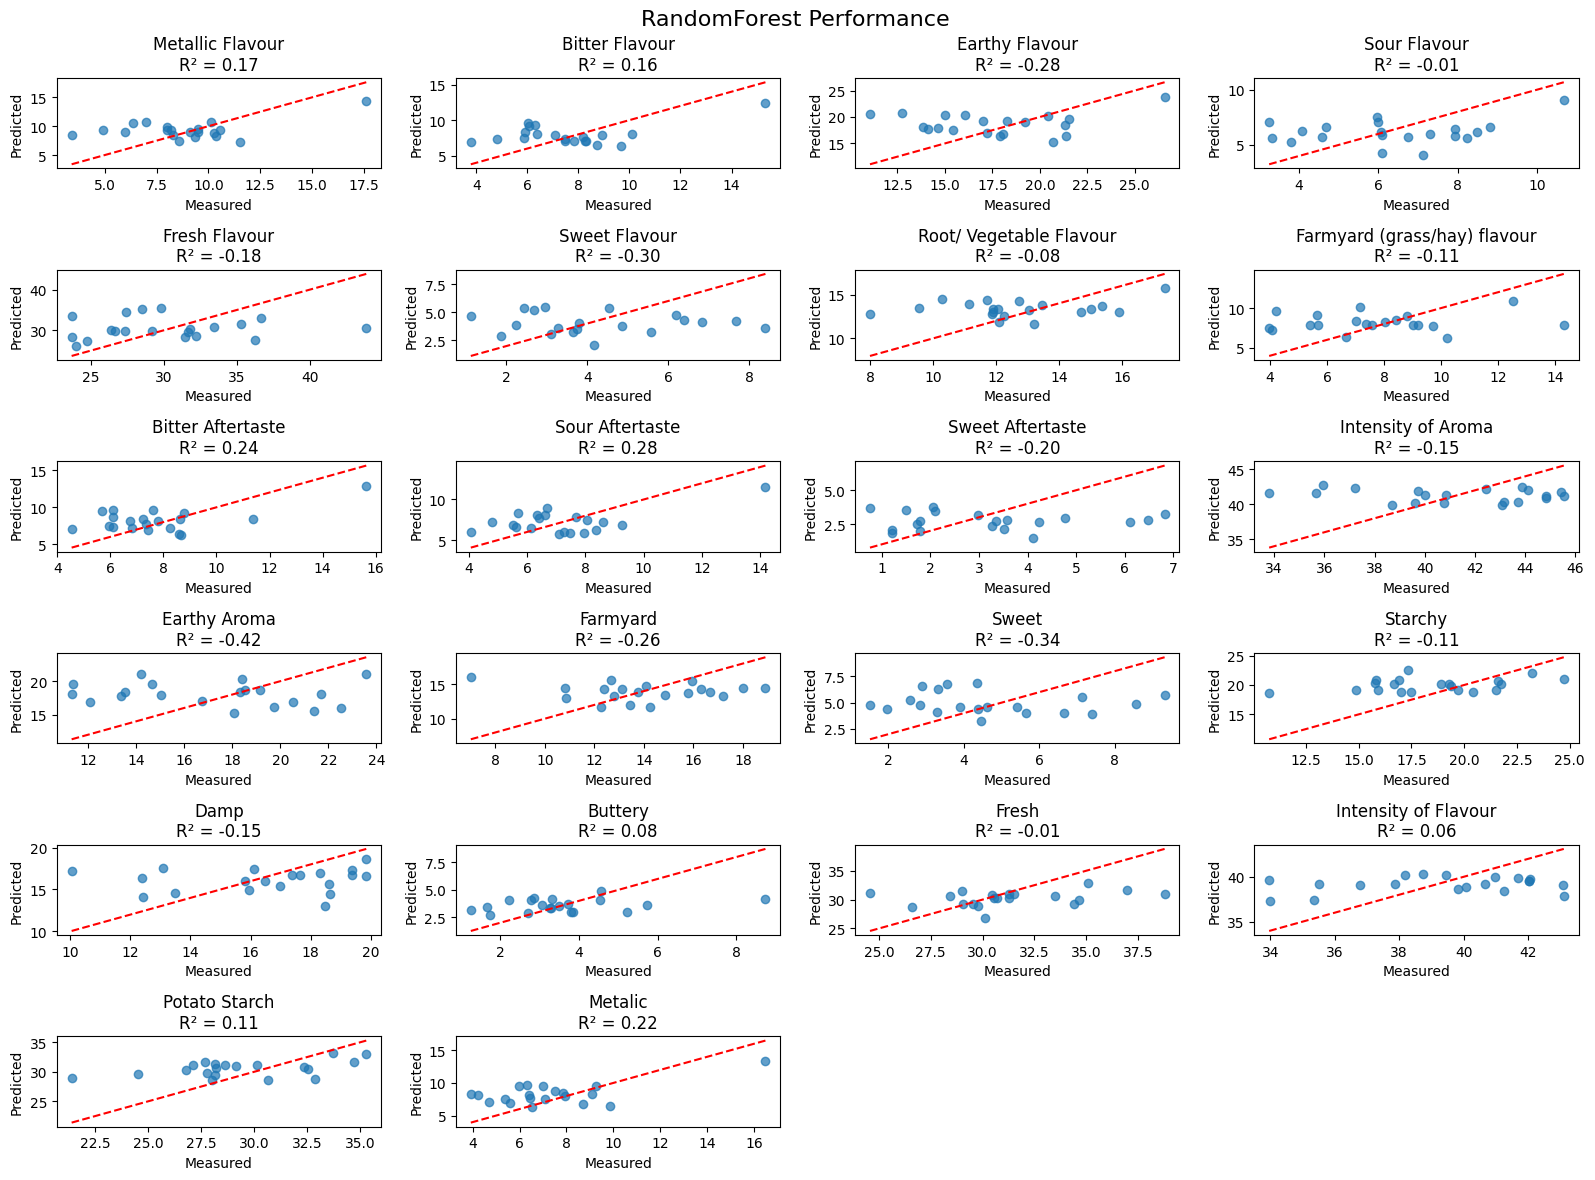

In [ ]:

#  Train RF with matched data only (20 varieties)
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_scaled[:20], Y_scaled)  # Y_scaled is standardized sensory traits

# Predict for all 94 varieties 
predicted_Y_scaled = rf.predict(all_X_scaled)
predicted_Y = scaler_Y.inverse_transform(predicted_Y_scaled)

# Collect results 
rf_df = pd.DataFrame(predicted_Y, columns=sensory_cols)

# Attach correct Variety names
if "Variety" in aroma_pivot_reset.columns:
    rf_df["Variety"] = aroma_pivot_reset["Variety"].values
elif "index" in aroma_pivot_reset.columns:
    rf_df["Variety"] = aroma_pivot_reset["index"].values
else:
    raise ValueError("No Variety column found in aroma_pivot_reset")

rf_df["MAF_score"] = rf_df[sensory_cols].mean(axis=1)

print("\nRandomForest - Top 10 Varieties:")
print(rf_df[["Variety","MAF_score"]].sort_values("MAF_score", ascending=False).head(10))

# Prepare true vs predicted for first 20 varieties 
Y_true = Y.values               # convert DataFrame -> numpy
Y_pred = predicted_Y[:20]       # predicted values for first 20

#  Plot function 
def plot_predicted_vs_measured(Y_true, Y_pred, trait_names, title="Model Performance"):
    n_traits = len(trait_names)
    ncols = 4
    nrows = (n_traits + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 12))
    axes = axes.flatten()
    
    for i, trait in enumerate(trait_names):
        ax = axes[i]
        x = Y_true[:, i]
        y = Y_pred[:, i]
        
        ax.scatter(x, y, alpha=0.7)
        ax.plot([x.min(), x.max()], [x.min(), x.max()], "r--")
        
        r2 = r2_score(x, y)
        ax.set_title(f"{trait}\nR² = {r2:.2f}")
        ax.set_xlabel("Measured")
        ax.set_ylabel("Predicted")
    
    # Hide unused subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_predicted_vs_measured(Y_true, Y_pred, sensory_cols, title="RandomForest Performance")


Only Bitter Aftertaste (R² = 0.25) and Sour Aftertaste (R² = 0.28) have some predictive value.

Other traits, like Sweet Flavour (R² = -0.29) or Root/Vegetable (R² = -0.10), show poor fit.

# Elasticnet



ElasticNet - Top 10 Varieties:
         Variety  MAF_score
39       EVEREST  17.966074
43       FELSINA  17.279041
46      FLAMENCO  17.186617
29  CLEARWATER R  17.010760
11       ARIZONA  16.936838
86      SUPERIOR  16.868769
61      MONALISA  16.848810
87      SYMFONIA  16.786318
0          ADORA  16.745130
3         ALTHEA  16.678693


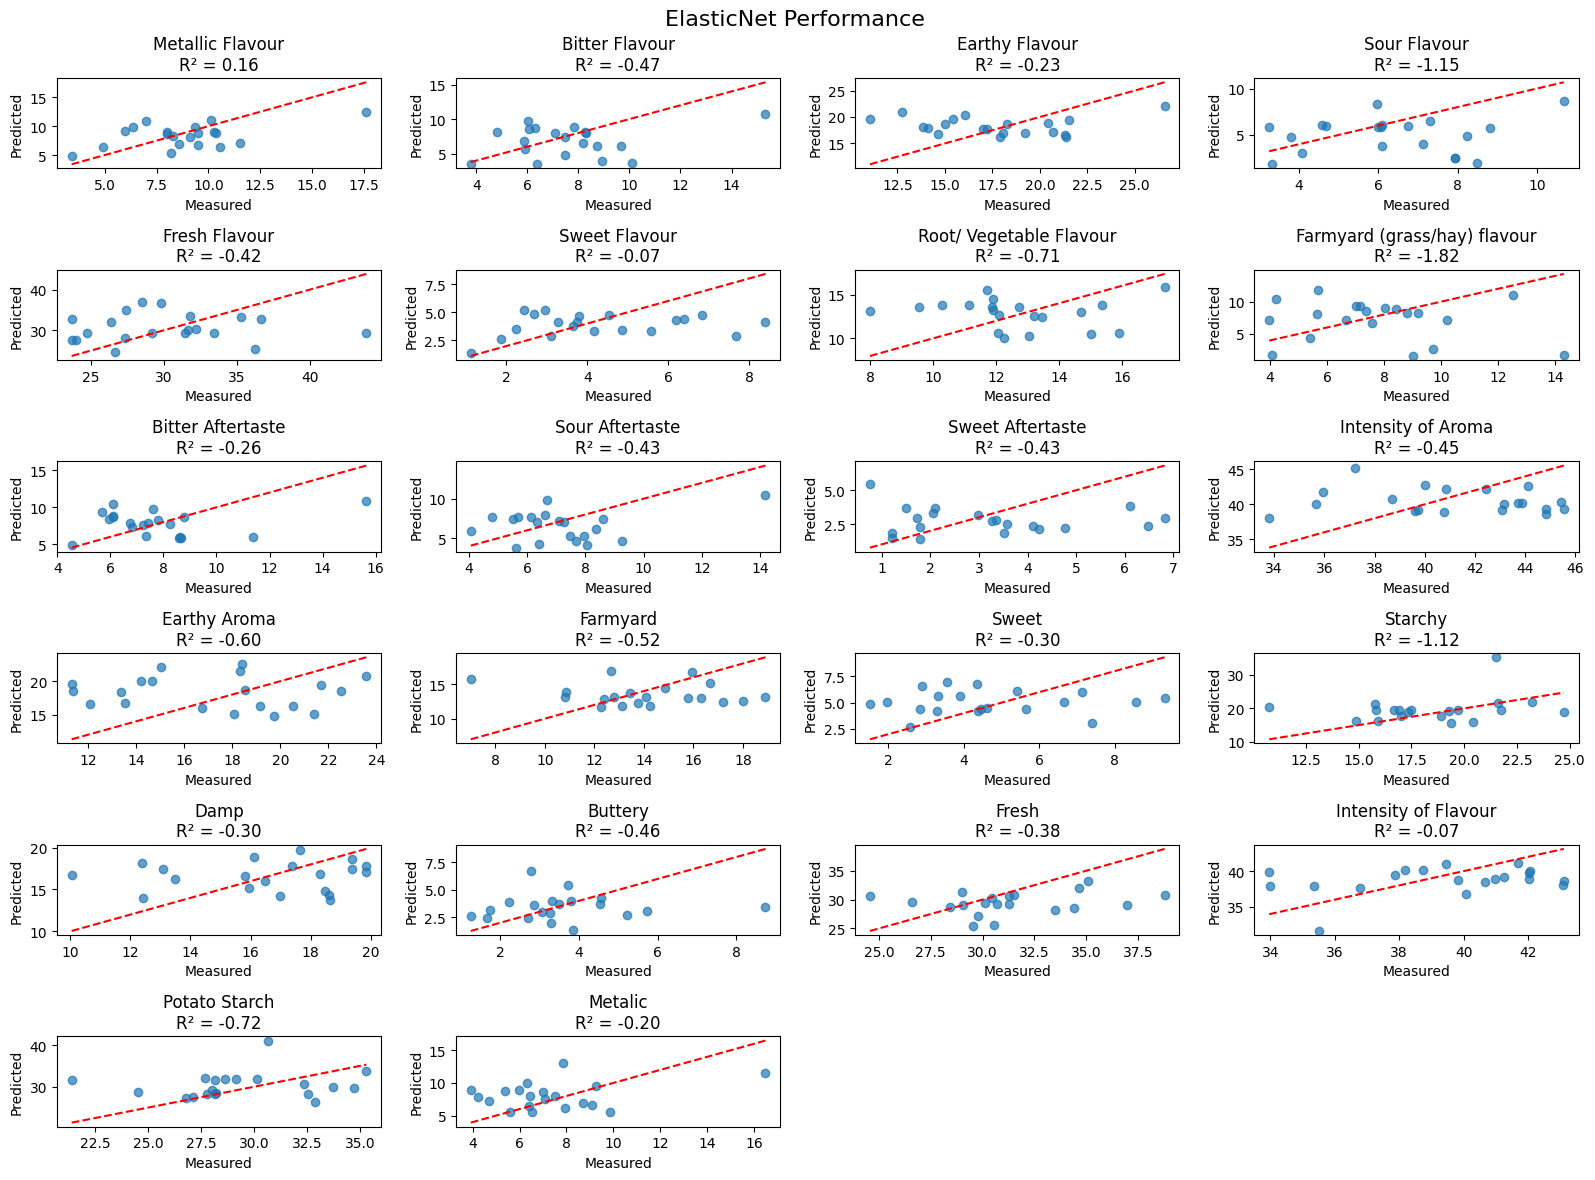

In [ ]:

#Train ElasticNet with matched data (20 varieties)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=10000)
elastic.fit(X_scaled[:20], Y_scaled)

# Predict  all 94
elastic_pred_scaled = elastic.predict(all_X_scaled)

# ElasticNet outputs 1D if only 1 target, so reshape
if elastic_pred_scaled.ndim == 1:
    elastic_pred_scaled = elastic_pred_scaled.reshape(-1, 1)

elastic_pred = scaler_Y.inverse_transform(elastic_pred_scaled)

# Put predictions into a dataframe
elastic_df = pd.DataFrame(elastic_pred, columns=sensory_cols)

# Attach correct Variety names
if "Variety" in aroma_pivot_reset.columns:
    elastic_df["Variety"] = aroma_pivot_reset["Variety"].values
elif "index" in aroma_pivot_reset.columns:
    elastic_df["Variety"] = aroma_pivot_reset["index"].values

elastic_df["MAF_score"] = elastic_df[sensory_cols].mean(axis=1)

print("\nElasticNet - Top 10 Varieties:")
print(elastic_df[["Variety", "MAF_score"]].sort_values("MAF_score", ascending=False).head(10))

# Compare measured vs predicted (first 20 varieties with sensory labels)
Y_true = Y.values          
Y_pred = elastic_pred[:20] # predicted for first 20

plot_predicted_vs_measured(Y_true, Y_pred, sensory_cols, title="ElasticNet Performance")


Metallic Flavour (R² = 0.16) is the only one slightly positive, but still weak

# Plsr, Randomforest, Elasticnet  hypertuning and cross validation

Model                         ElasticNet  PLSR  RandomForest
Trait                                                       
Bitter Aftertaste                  -0.01 -0.77         -0.06
Bitter Flavour                     -0.03 -1.24         -0.07
Buttery                            -0.16 -1.61          0.14
Damp                               -0.26 -2.55         -0.64
Earthy Aroma                       -0.09 -0.44          0.07
Earthy Flavour                     -0.02 -1.00          0.05
Farmyard                           -0.02 -0.62          0.02
Farmyard (grass/hay) flavour       -0.03 -0.26          0.01
Fresh                              -0.19 -1.61         -0.30
Fresh Flavour                      -0.21 -0.90         -0.05
Intensity of Aroma                 -0.04 -0.32         -0.24
Intensity of Flavour               -0.10 -0.02         -0.53
Metalic                            -0.06 -0.77         -0.23
Metallic Flavour                   -0.06 -1.68         -0.18
Potato Starch           

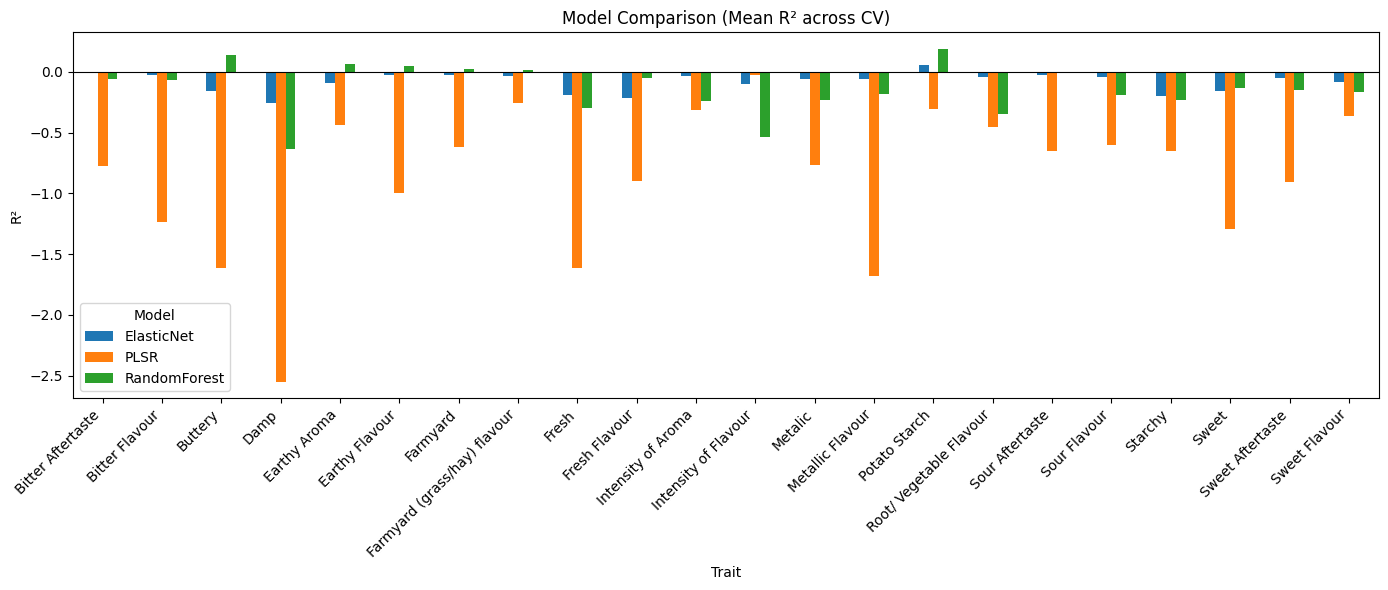

In [ ]:

X = merged_aroma_sensory[compound_cols].values
Y = merged_aroma_sensory[sensory_cols].values

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

#  Models + parameter grids 
models = {
    "PLSR": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", PLSRegression())
        ]),
        {"model__n_components": [2, 3, 4, 5]}
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {"n_estimators": [100, 200],
         "max_depth": [None, 5, 10],
         "min_samples_split": [2, 5]}
    ),
    "ElasticNet": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(max_iter=5000))
        ]),
        {"model__alpha": [0.01, 0.1, 1, 10],
         "model__l1_ratio": [0.2, 0.5, 0.8]}
    )
}

# Loop over models and sensory traits
for model_name, (estimator, param_grid) in models.items():
    for j, trait in enumerate(sensory_cols):
        y = Y[:, j]

        # Grid search CV
        grid = GridSearchCV(estimator, param_grid, cv=cv, scoring="r2", n_jobs=-1)
        grid.fit(X, y)

        # Cross-val predictions
        y_pred = cross_val_predict(grid.best_estimator_, X, y, cv=cv)

        # R²
        r2 = r2_score(y, y_pred)
        results.append({"Model": model_name, "Trait": trait, "R2": r2})

results_df = pd.DataFrame(results)
summary = results_df.pivot(index="Trait", columns="Model", values="R2")
print(summary.round(2))

summary.plot(kind="bar", figsize=(14, 6))
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Model Comparison (Mean R² across CV)")
plt.ylabel("R²")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


ElasticNet: shrinks many coefficients → most traits have R² ≈ 0 or negative.

PLSR: quite unstable, giving very negative R² (overfitting risk, maybe too many components).

RandomForest: slightly more stable, sometimes near 0 or small positive R², but still limited predictive power

# Corrolation of aroma compounds and flavor


In [ ]:
merged_aroma_sensory = merged_aroma_sensory.loc[:, merged_aroma_sensory.nunique() > 1]


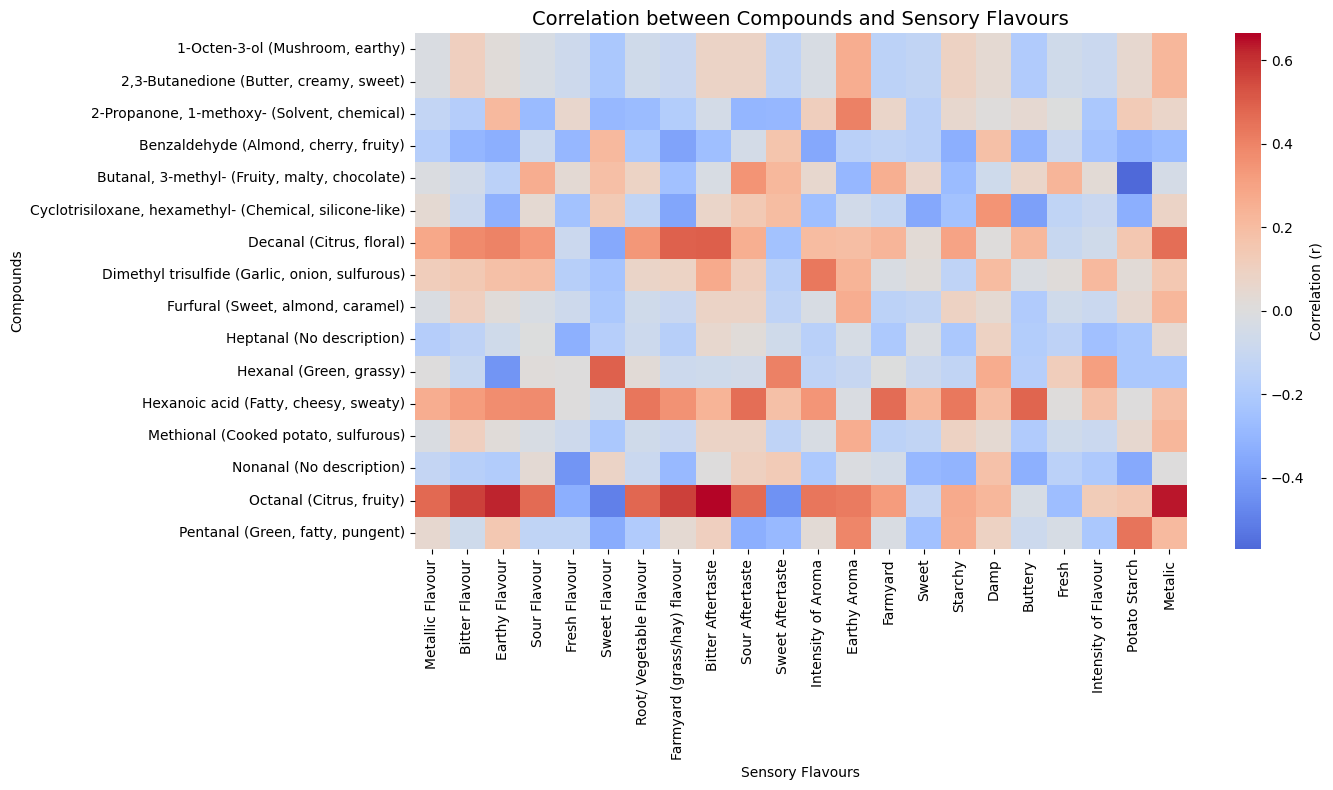

In [ ]:
# --- Step 1: clean column names ---
merged_aroma_sensory.columns = merged_aroma_sensory.columns.str.strip()   # remove leading/trailing spaces
merged_aroma_sensory = merged_aroma_sensory.loc[:, ~merged_aroma_sensory.columns.duplicated()]  # drop duplicate cols

# --- Step 2: define compound & sensory columns properly ---
compound_cols = [c for c in merged_aroma_sensory.columns if "(" in c and c not in sensory_cols]

sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste", 'Earthy Aroma',
    'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Potato Starch','Metalic'
]

# Remove duplicates safely
sensory_cols = list(dict.fromkeys(sensory_cols))

# --- Step 3: correlation block ---
corr_matrix = merged_aroma_sensory[compound_cols + sensory_cols].corr()
corr_block = corr_matrix.loc[compound_cols, sensory_cols]

# --- Step 4: heatmap ---
plt.figure(figsize=(14, 8))
sns.heatmap(corr_block, cmap="coolwarm", center=0, annot=False, cbar_kws={'label': 'Correlation (r)'})
plt.title("Correlation between Compounds and Sensory Flavours", fontsize=14)
plt.ylabel("Compounds")
plt.xlabel("Sensory Flavours")
plt.tight_layout()
plt.show()


Benzaldehyde (almond, cherry, fruity) has a negative correlation with Bitter Flavour and Sour Flavour but some positive with Sweet Flavour.

Methional (cooked potato, sulfurous) has mild correlations, but tends to be negative with Sweet Aftertaste.

1-Octen-3-ol (mushroom, earthy) shows weak to moderate positive correlation with Bitter.

# Showing the corrolation by barplot

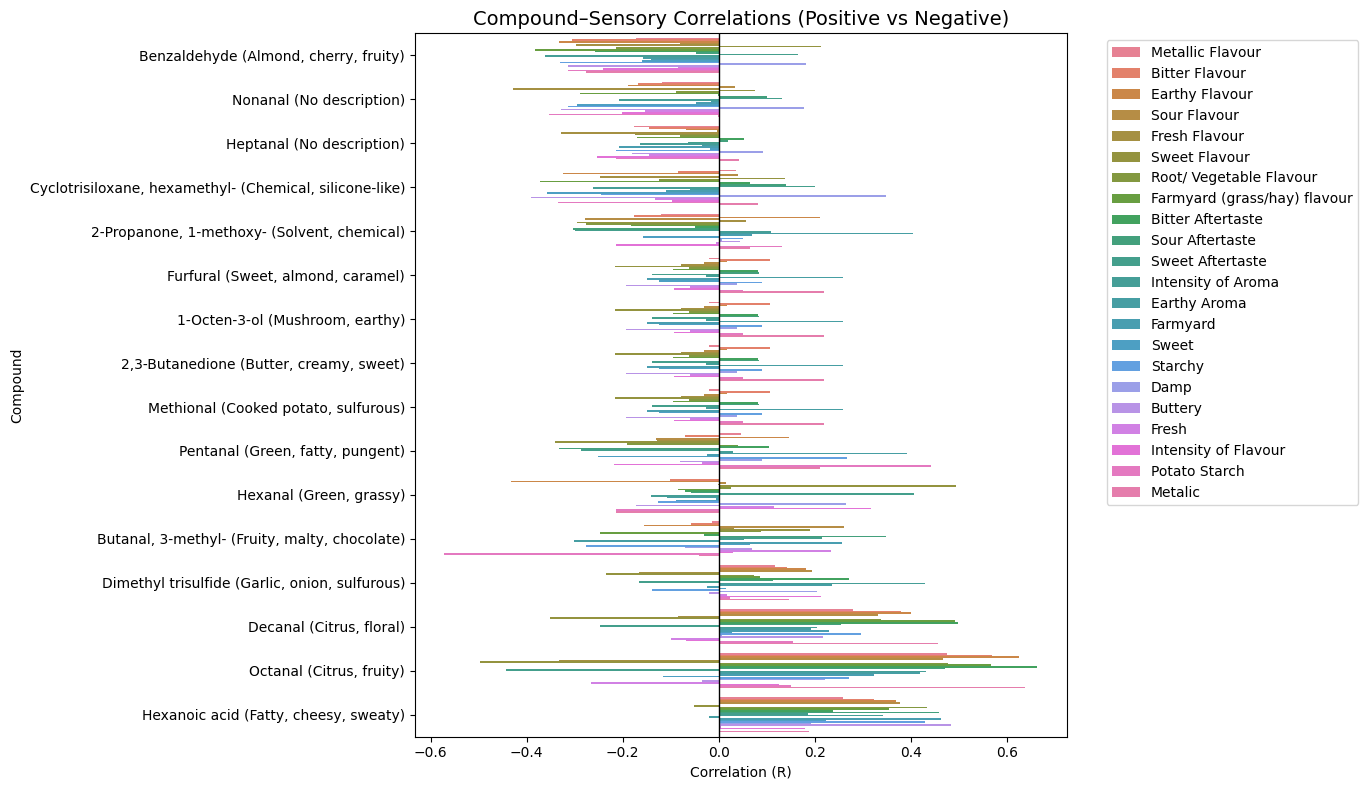

In [ ]:

# Melt the correlation block for plotting
corr_melt = corr_block.reset_index().melt(
    id_vars="index", var_name="Sensory", value_name="Correlation"
)
corr_melt.rename(columns={"index": "Compound"}, inplace=True)

# Sort compounds by average correlation
compound_order = corr_melt.groupby("Compound")["Correlation"].mean().sort_values().index

# Bi-directional barplot
plt.figure(figsize=(14, 8))
sns.barplot(
    data=corr_melt,
    x="Correlation", y="Compound", hue="Sensory",
    order=compound_order, dodge=True
)

plt.axvline(0, color="black", lw=1)
plt.title("Compound–Sensory Correlations (Positive vs Negative)", fontsize=14)
plt.xlabel("Correlation (R)")
plt.ylabel("Compound")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


we can  see Which varieties are more related to a given flavor perception,This is a projection in the shared compound space. By selecting a flavor trait, we can identify the potato varieties most related to that sensory perception


# Hierarchical clustering on PCA scores

When we projected the sensory traits into the compound PCA space, the outlier set shifted ,some varieties that were chemically unusual became less extreme once flavor perception was considered and now instead of 5 outliers we have 2 outliers.

better for overall diversity analysis, not as strong for predicting flavor

# Predicting Sensory Scores for Non-panel Varieties using KNN and PCA

Explained variance ratio (panel PCA): [0.42093716 0.19657427 0.08699608]
        PC1       PC2       PC3    Variety  is_panel
0  7.733239  3.061966 -2.091810      ADORA      True
1  1.339365 -3.929125  1.404283      AGRIA      True
2 -0.863593  0.614121  3.222238     BERBER      True
3  1.489505 -3.490208  0.538136  BILDTSTAR      True
4 -2.551224 -0.617991  1.316727     BINTJE      True


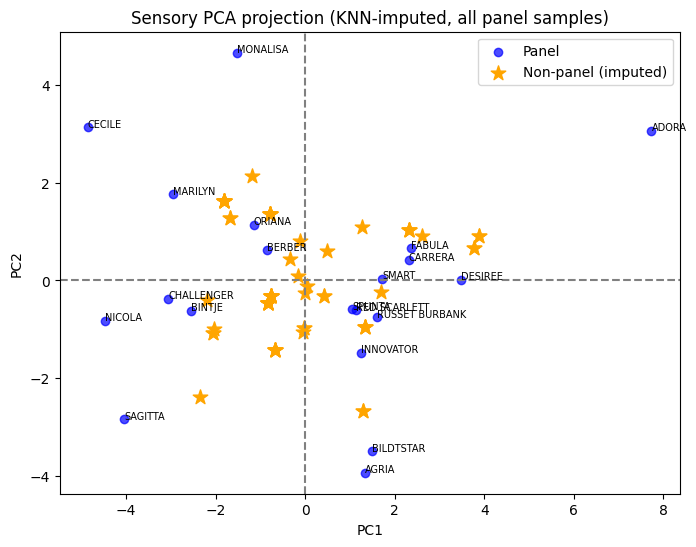

In [ ]:
from sklearn.neighbors import NearestNeighbors
from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Merge aroma + sensory
merged = aroma_df.merge(sensory_summary, on="Variety", how="left")
merged["is_panel"] = merged["Variety"].isin(sensory_summary["Variety"])

# Split panel vs non-panel
panel_df = merged[merged["is_panel"]].reset_index(drop=True)
nonpanel_df = merged[~merged["is_panel"]].reset_index(drop=True)

# Define columns
sensory_cols = [c for c in sensory_summary.columns if c.upper() != "VARIETY"]
aroma_cols = [c for c in aroma_df.columns if c.upper() != "VARIETY"]

# No outlier removal
Y_panel = panel_df[sensory_cols].fillna(0)
X_panel = panel_df[aroma_cols].fillna(0)

# KNN-imputation of sensory traits for non-panel
X_nonpanel = nonpanel_df[aroma_cols].fillna(0)

k = 3
nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
nn.fit(X_panel)

distances, indices = nn.kneighbors(X_nonpanel)

# Impute sensory traits as mean of nearest neighbors
Y_nonpanel_pred = np.array([Y_panel.iloc[idx].mean(axis=0) for idx in indices])

# PCA on sensory traits (panel only, then project)
scaler = StandardScaler().fit(Y_panel.values)
X_panel_scaled = scaler.transform(Y_panel.values)
X_nonpanel_scaled = scaler.transform(Y_nonpanel_pred)

pca = PCA(n_components=3, random_state=0)
pcs_panel = pca.fit_transform(X_panel_scaled)
pcs_nonpanel = pca.transform(X_nonpanel_scaled)

# Build combined DataFrame
panel_pcs = pd.DataFrame(pcs_panel, columns=["PC1", "PC2", "PC3"])
panel_pcs["Variety"] = panel_df["Variety"].values
panel_pcs["is_panel"] = True

nonpanel_pcs = pd.DataFrame(pcs_nonpanel, columns=["PC1", "PC2", "PC3"])
nonpanel_pcs["Variety"] = nonpanel_df["Variety"].values
nonpanel_pcs["is_panel"] = False

pc_df = pd.concat([panel_pcs, nonpanel_pcs], ignore_index=True)

# Save
pc_df.to_csv("sensory_pca_projection_knn_no_outlier_removal.csv", index=False)

print("Explained variance ratio (panel PCA):", pca.explained_variance_ratio_)
print(pc_df.head())

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(pc_df.loc[pc_df["is_panel"], "PC1"],
            pc_df.loc[pc_df["is_panel"], "PC2"],
            c="blue", label="Panel", alpha=0.7)
plt.scatter(pc_df.loc[~pc_df["is_panel"], "PC1"],
            pc_df.loc[~pc_df["is_panel"], "PC2"],
            c="orange", marker="*", s=120, label="Non-panel (imputed)")

for i, row in pc_df.iterrows():
    if row["is_panel"]:
        plt.text(row["PC1"], row["PC2"], row["Variety"], fontsize=7)

plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Sensory PCA projection (KNN-imputed, all panel samples)")
plt.legend()
plt.show()


In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2","PC3"],
    index=sensory_cols
)
print(loadings)
import pandas as pd

# After you fit PCA
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=sensory_cols
)

# Save to CSV
loadings.to_csv("sensory_pca_loadings.csv")


                                   PC1       PC2       PC3
Metallic Flavour              0.268839  0.146071 -0.102859
Bitter Flavour                0.277107  0.192741 -0.114210
Earthy Flavour                0.263765  0.012843  0.018140
Sour Flavour                  0.234347  0.239000 -0.111888
Fresh Flavour                -0.212229  0.212621  0.169984
Sweet Flavour                -0.217310  0.272229  0.063188
Root/ Vegetable Flavour       0.205287  0.221127  0.226094
Farmyard (grass/hay) flavour  0.261390  0.129831  0.186622
Bitter Aftertaste             0.261313  0.133993 -0.222205
Sour Aftertaste               0.229686  0.263213 -0.237245
Sweet Aftertaste             -0.225728  0.236170  0.048115
Intensity of Aroma            0.175498  0.122044  0.348528
Earthy Aroma                  0.234742 -0.230463  0.135197
Farmyard                      0.171048  0.147784  0.079219
Sweet                        -0.143885  0.284263  0.182459
Starchy                       0.170485 -0.089354  0.4624

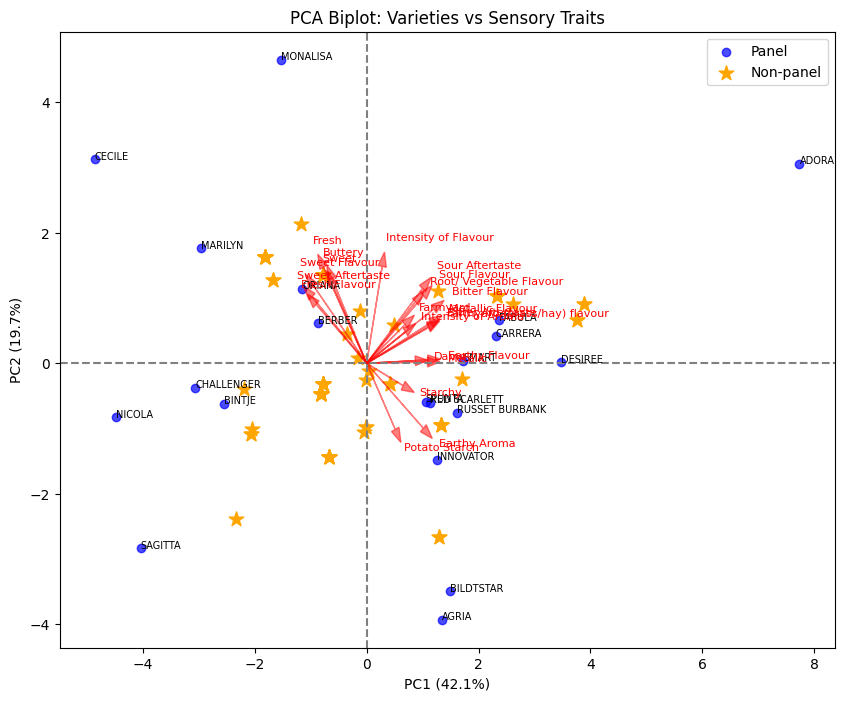

In [ ]:

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2","PC3"],
    index=sensory_cols
)

plt.figure(figsize=(10,8))

#  Samples (varieties)
plt.scatter(pc_df.loc[pc_df["is_panel"], "PC1"],
            pc_df.loc[pc_df["is_panel"], "PC2"],
            c="blue", label="Panel", alpha=0.7)
plt.scatter(pc_df.loc[~pc_df["is_panel"], "PC1"],
            pc_df.loc[~pc_df["is_panel"], "PC2"],
            c="orange", marker="*", s=120, label="Non-panel")

# Add variety labels (only panel for clarity)
for i, row in pc_df.iterrows():
    if row["is_panel"]:
        plt.text(row["PC1"], row["PC2"], row["Variety"], fontsize=7)

# Loadings 
scaling_factor = 5  
for feature in sensory_cols:
    x = loadings.loc[feature, "PC1"] * scaling_factor
    y = loadings.loc[feature, "PC2"] * scaling_factor
    plt.arrow(0, 0, x, y,
              color="red", alpha=0.5, head_width=0.15, length_includes_head=True)
    plt.text(x*1.1, y*1.1, feature, color="red", fontsize=8)

# Axes and labels
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA Biplot: Varieties vs Sensory Traits")
plt.legend()
plt.show()


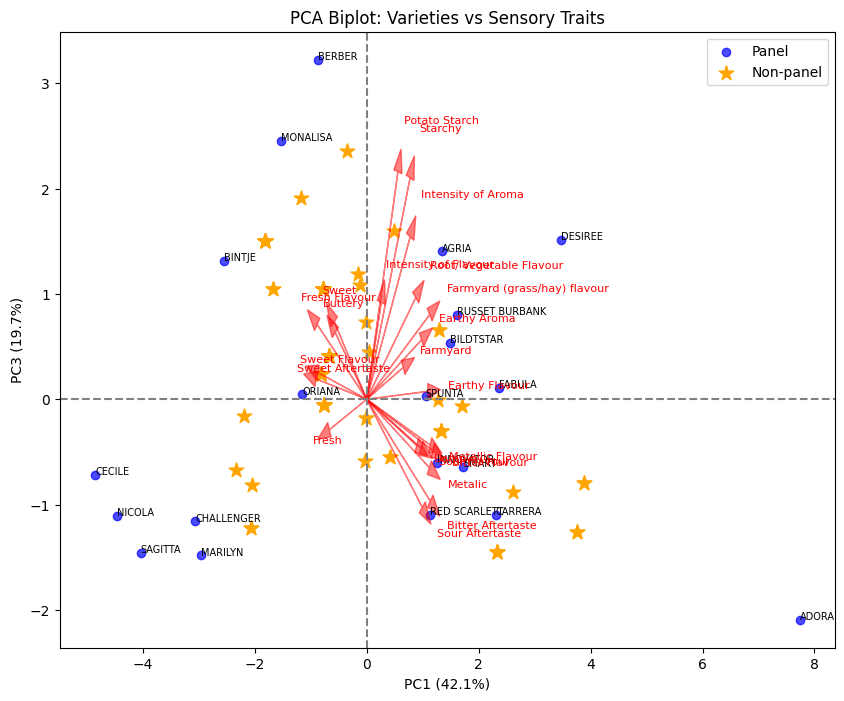

In [ ]:
plt.figure(figsize=(10,8))

#  Samples (varieties)
plt.scatter(pc_df.loc[pc_df["is_panel"], "PC1"],
            pc_df.loc[pc_df["is_panel"], "PC3"],
            c="blue", label="Panel", alpha=0.7)
plt.scatter(pc_df.loc[~pc_df["is_panel"], "PC1"],
            pc_df.loc[~pc_df["is_panel"], "PC3"],
            c="orange", marker="*", s=120, label="Non-panel")

# Add variety labels (only panel for clarity)
for i, row in pc_df.iterrows():
    if row["is_panel"]:
        plt.text(row["PC1"], row["PC3"], row["Variety"], fontsize=7)

# Loadings 
scaling_factor = 5  
for feature in sensory_cols:
    x = loadings.loc[feature, "PC1"] * scaling_factor
    y = loadings.loc[feature, "PC3"] * scaling_factor
    plt.arrow(0, 0, x, y,
              color="red", alpha=0.5, head_width=0.15, length_includes_head=True)
    plt.text(x*1.1, y*1.1, feature, color="red", fontsize=8)

# Axes and labels
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC3 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA Biplot: Varieties vs Sensory Traits")
plt.legend()
plt.show()

In [ ]:
summary = []

for i, row in pc_df.iterrows():
    taste = []

    # PC1 interpretation
    if row["PC1"] > 1.5:  
        taste.append("Bitter/Sour/Metallic")
    elif row["PC1"] < -1.5:
        taste.append("Mild/Less bitter")

    # PC2 interpretation
    if row["PC2"] > 1.0:
        taste.append("Sweet/Fresh")
    elif row["PC2"] < -1.0:
        taste.append("Earthy/Vegetal")

    # اگر هیچ برچسبی پیدا نشد
    if not taste:
        taste_label = "Unclassified"
    else:
        taste_label = " + ".join(taste)

    summary.append([row["Variety"], row["PC1"], row["PC2"], taste_label])

summary_df = pd.DataFrame(
    summary,
    columns=["Variety", "PC1", "PC2", "Dominant sensory axis"]
).set_index("Variety")

print(summary_df.head(20))

summary_df.to_csv("variety_sensory_summary.csv")


                     PC1       PC2               Dominant sensory axis
Variety                                                               
ADORA           7.733239  3.061966  Bitter/Sour/Metallic + Sweet/Fresh
AGRIA           1.339365 -3.929125                      Earthy/Vegetal
BERBER         -0.863593  0.614121                        Unclassified
BILDTSTAR       1.489505 -3.490208                      Earthy/Vegetal
BINTJE         -2.551224 -0.617991                    Mild/Less bitter
CARRERA         2.308387  0.417122                Bitter/Sour/Metallic
CECILE         -4.855080  3.127277      Mild/Less bitter + Sweet/Fresh
CHALLENGER     -3.062536 -0.370892                    Mild/Less bitter
DESIREE         3.468957  0.017790                Bitter/Sour/Metallic
FABULA          2.371309  0.657991                Bitter/Sour/Metallic
INNOVATOR       1.254727 -1.477418                      Earthy/Vegetal
MARILYN        -2.958122  1.760050      Mild/Less bitter + Sweet/Fresh
MONALI

For varieties without panel data, sensory scores were estimated using a k-nearest neighbors (KNN) approach based on aroma profiles. Each non-panel variety was compared to panel varieties in aroma space, and its predicted sensory profile was calculated as the average of the sensory scores of its closest panel neighbors. These imputed sensory scores allowed non-panel varieties to be assigned positions in the PCA sensory space alongside the panel varieties.